In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing Libraries

In [6]:
import warnings
warnings.filterwarnings('ignore')
print("Warning suppression active.")

Warning suppression active.


In [7]:
# Importing libraries 

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
 
import cv2
from PIL import Image
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Model constants / configs



In the cell below, I define the main configuration settings for the project. This includes the random seed, dataset paths, image size, batch size, validation split, number of epochs, and the four class names: glioma, meningioma, notumor, and pituitary.

I use this cell to keep the experiment organized and reproducible. By defining these constants in one place, I can make sure that the same image size, batch size, class order, and output folder are used consistently throughout the notebook.

In [8]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# checkpoint ko path haru

BASE_DIR   = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
TRAIN_DIR  = BASE_DIR / "Training"
TEST_DIR   = BASE_DIR / "Testing"
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Configsa

IMG_SIZE    = 224          # Input image size (224x224)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
VAL_SPLIT   = 0.2         # 20% of training data → validation

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

print("="*60)
print("  BRAIN TUMOR MRI - CNN From Scratch")
print("="*60)
print(f"  Image Size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size  : {BATCH_SIZE}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Classes     : {CLASS_NAMES}")
print("="*60)


  BRAIN TUMOR MRI - CNN From Scratch
  Image Size  : 224x224
  Batch Size  : 32
  Epochs      : 50
  Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']


### Output --

In this output, it shows the main configuration used for the brain tumor MRI classification task. The notebook is set up for a **CNN from scratch**, using an image size of **224 by 224**, a batch size of **32**, and a maximum of **50 epochs**. The four target classes are **glioma**, **meningioma**, **notumor**, and **pituitary**. This confirms that the problem is a four class image classification task rather than binary classification.

The image size matters because every MRI scan must be resized to the same input shape before it can be passed into a convolutional neural network. A size of 224 by 224 is common because it is large enough to preserve important brain structure while still being practical for GPU training. The batch size of 32 means the model updates its weights after seeing 32 images at a time. The maximum epoch value gives the model enough time to learn, while callbacks later prevent unnecessary training.

I conclude that this cell defines the foundation of the experiment. Before any model can be trained, the dataset path, class names, image size, batch size, output folder, and training limits must be fixed clearly.

# EDA 




In the cell below, I examine the structure of the dataset by counting how many MRI images are available for each class in the training and testing folders. This gives me the first numerical overview of the dataset before any modelling begins.

This step is important because a CNN can become biased if one class has many more images than the others. By checking the counts early, I can understand whether the dataset is balanced and whether later metrics such as accuracy can be interpreted fairly.

In [9]:
print("\n[EDA] Analyzing dataset structure...")

def count_images(directory: Path) -> dict:
    """Count images per class in a directory."""
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = directory / cls
        if cls_path.exists():
            counts[cls] = len(list(cls_path.glob("*.jpg")) +
                              list(cls_path.glob("*.jpeg")) +
                              list(cls_path.glob("*.png")))
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())

print(f"\n  Training samples : {total_train}")
print(f"  Testing  samples : {total_test}")
print(f"  Total            : {total_train + total_test}")
print("\n  Per-class breakdown:")
print(f"  {'Class':<15} {'Train':>8} {'Test':>8} {'Total':>8}")
print("  " + "-"*42)
for cls in CLASS_NAMES:
    print(f"  {cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8} "
          f"{train_counts[cls]+test_counts[cls]:>8}")


[EDA] Analyzing dataset structure...

  Training samples : 5600
  Testing  samples : 1600
  Total            : 7200

  Per-class breakdown:
  Class              Train     Test    Total
  ------------------------------------------
  glioma              1400      400     1800
  meningioma          1400      400     1800
  notumor             1400      400     1800
  pituitary           1400      400     1800


### Output  --

In this output, it shows that the dataset contains **5600 training samples**, **1600 testing samples**, and **7200 total MRI images**. The per class breakdown shows that each of the four classes has exactly **1400 training images** and **400 testing images**, giving **1800 images per class** in total. The classes are **glioma**, **meningioma**, **notumor**, and **pituitary**.

This result is important because it shows that the dataset is perfectly balanced across all four classes. Unlike an imbalanced dataset where one class dominates, this structure gives the CNN an equal number of examples for every tumor category. As a result, accuracy becomes more meaningful than it would be in a heavily imbalanced dataset, although precision, recall, and F1 score are still needed for detailed evaluation.

I conclude that the dataset is suitable for supervised multiclass classification. Since every class has the same number of samples, the model should not become biased simply because of class frequency. The next step is to visualize the distribution and inspect sample images so that I can understand the visual differences between the MRI categories.

###  

In the cell below, I create bar charts for the class distribution in the training and testing datasets. The chart allows me to visually compare how many images exist for glioma, meningioma, notumor, and pituitary classes.

I use this visualization because class distribution is easier to interpret from a graph than from numbers alone. If all bars have similar heights, it suggests that the model will receive a fair amount of data for each category during training and evaluation.

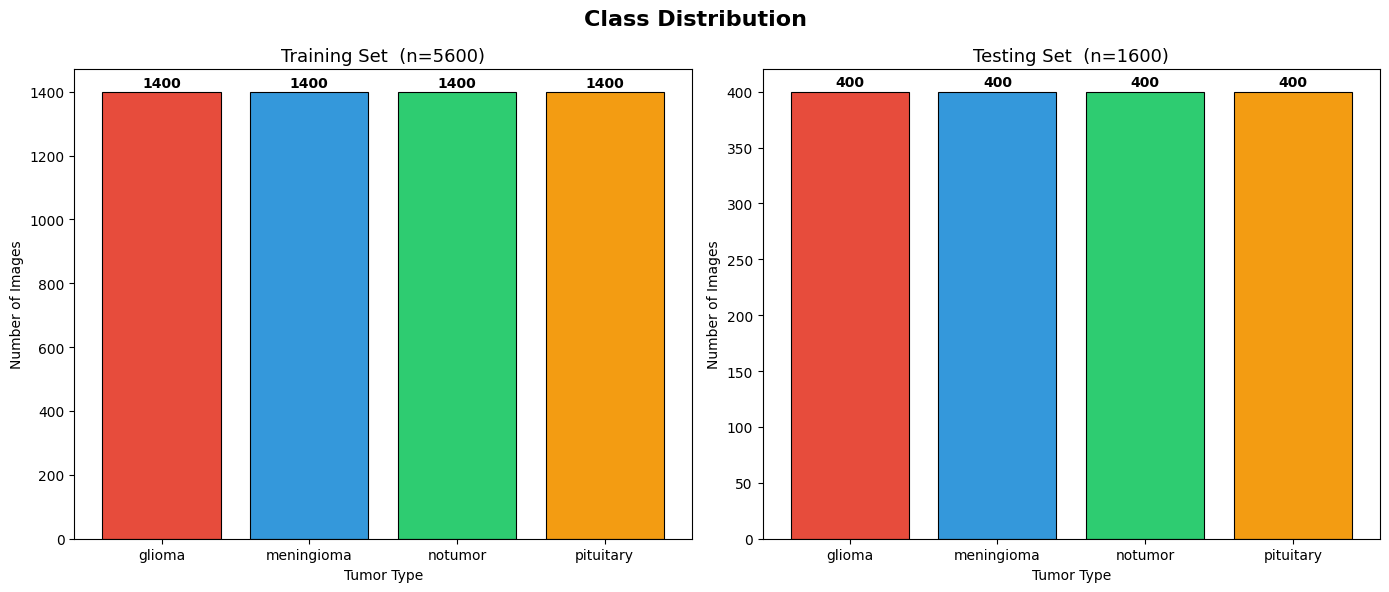

  [✓] Saved: 01_class_distribution.png


In [10]:
# 2.1 Class Distribution Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Distribution", fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Training
axes[0].bar(CLASS_NAMES, train_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title(f"Training Set  (n={total_train})", fontsize=13)
axes[0].set_xlabel("Tumor Type")
axes[0].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(train_counts.items()):
    axes[0].text(i, cnt + 15, str(cnt), ha='center', fontweight='bold')

# Testing
axes[1].bar(CLASS_NAMES, test_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title(f"Testing Set  (n={total_test})", fontsize=13)
axes[1].set_xlabel("Tumor Type")
axes[1].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(test_counts.items()):
    axes[1].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 01_class_distribution.png")

### Output  --

In this visualization, it show sbar charts showing the **class distribution** for the training set and the testing set. The x axis represents the four MRI categories, which are **glioma**, **meningioma**, **notumor**, and **pituitary**. The y axis represents the number of images in each category. In the training plot, every class has **1400 images**, and in the testing plot, every class has **400 images**.

This output confirms visually that the dataset is balanced. All four bars have the same height within each split, which means no class has more training influence than another. This is helpful for CNN training because the model receives equal exposure to tumor and non tumor examples. It also makes the later evaluation easier to interpret because a high accuracy score cannot be explained by simply predicting the majority class.

I conclude that class balancing is not a major problem in this dataset. Therefore, any confusion between categories later is more likely caused by visual similarity between MRI patterns rather than unfair class frequency. This chart supports the decision to continue with standard multiclass CNN training and detailed per class evaluation.

###  

In the cell below, I create pie charts to show the percentage share of each class in the training and testing datasets. This is another way to check whether the dataset is balanced across the four MRI categories.

This cell helps me explain the dataset composition in my report. Equal class proportions mean that no class dominates the data, so the model evaluation will be less affected by class imbalance.

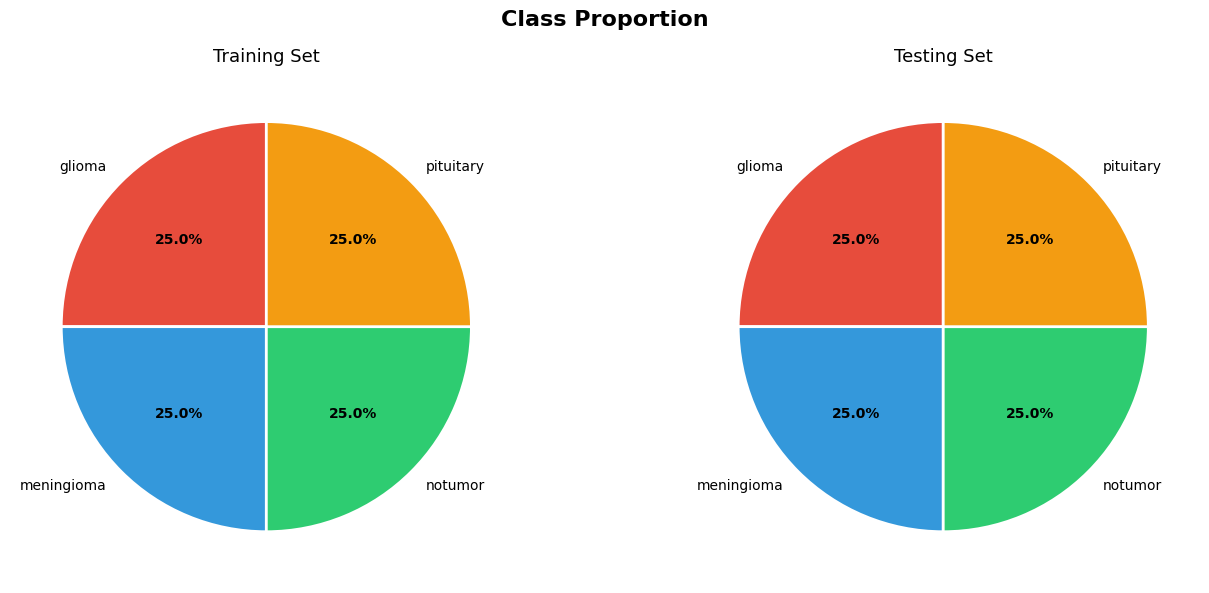

  [✓] Saved: 02_class_proportion.png


In [11]:
# 2.2 Class Imbalance (Pie Chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Proportion", fontsize=16, fontweight='bold')

for ax, counts, title in zip(
        axes,
        [train_counts, test_counts],
        ["Training Set", "Testing Set"]
    ):
    wedges, texts, autotexts = ax.pie(
        counts.values(),
        labels=CLASS_NAMES,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for text in autotexts:
        text.set_fontweight('bold')
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_class_proportion.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 02_class_proportion.png")

### Output  --

In this visualization, it shows                            two pie charts showing the **class proportions** in the training and testing sets. Each pie chart is divided into four equal sections for **glioma**, **meningioma**, **notumor**, and **pituitary**. Since each class has the same number of images, every category occupies approximately **25 percent** of the dataset in both splits.

This result gives another view of the same balance shown in the bar chart. The pie chart is useful because it focuses on percentage share rather than raw count. In this case, the equal sections show that no tumor type is underrepresented or overrepresented. This is important because a CNN trained on a balanced dataset has a fairer chance to learn features for each class.

I conclude that the dataset split is reliable for evaluation. The testing set also has equal class proportions, so the classification report later will fairly compare all four categories. This reduces the risk that performance looks good only because of one dominant class and gives more confidence in the model comparison.

###  

In the cell below, I display sample MRI images from each class. The function loads random images from the dataset folders and shows them in a grid so that I can visually inspect the data before model training.

This step is important because image classification is not only about numerical labels. By looking at actual glioma, meningioma, notumor, and pituitary scans, I can understand the visual patterns the CNN needs to learn and identify whether the task may be difficult.

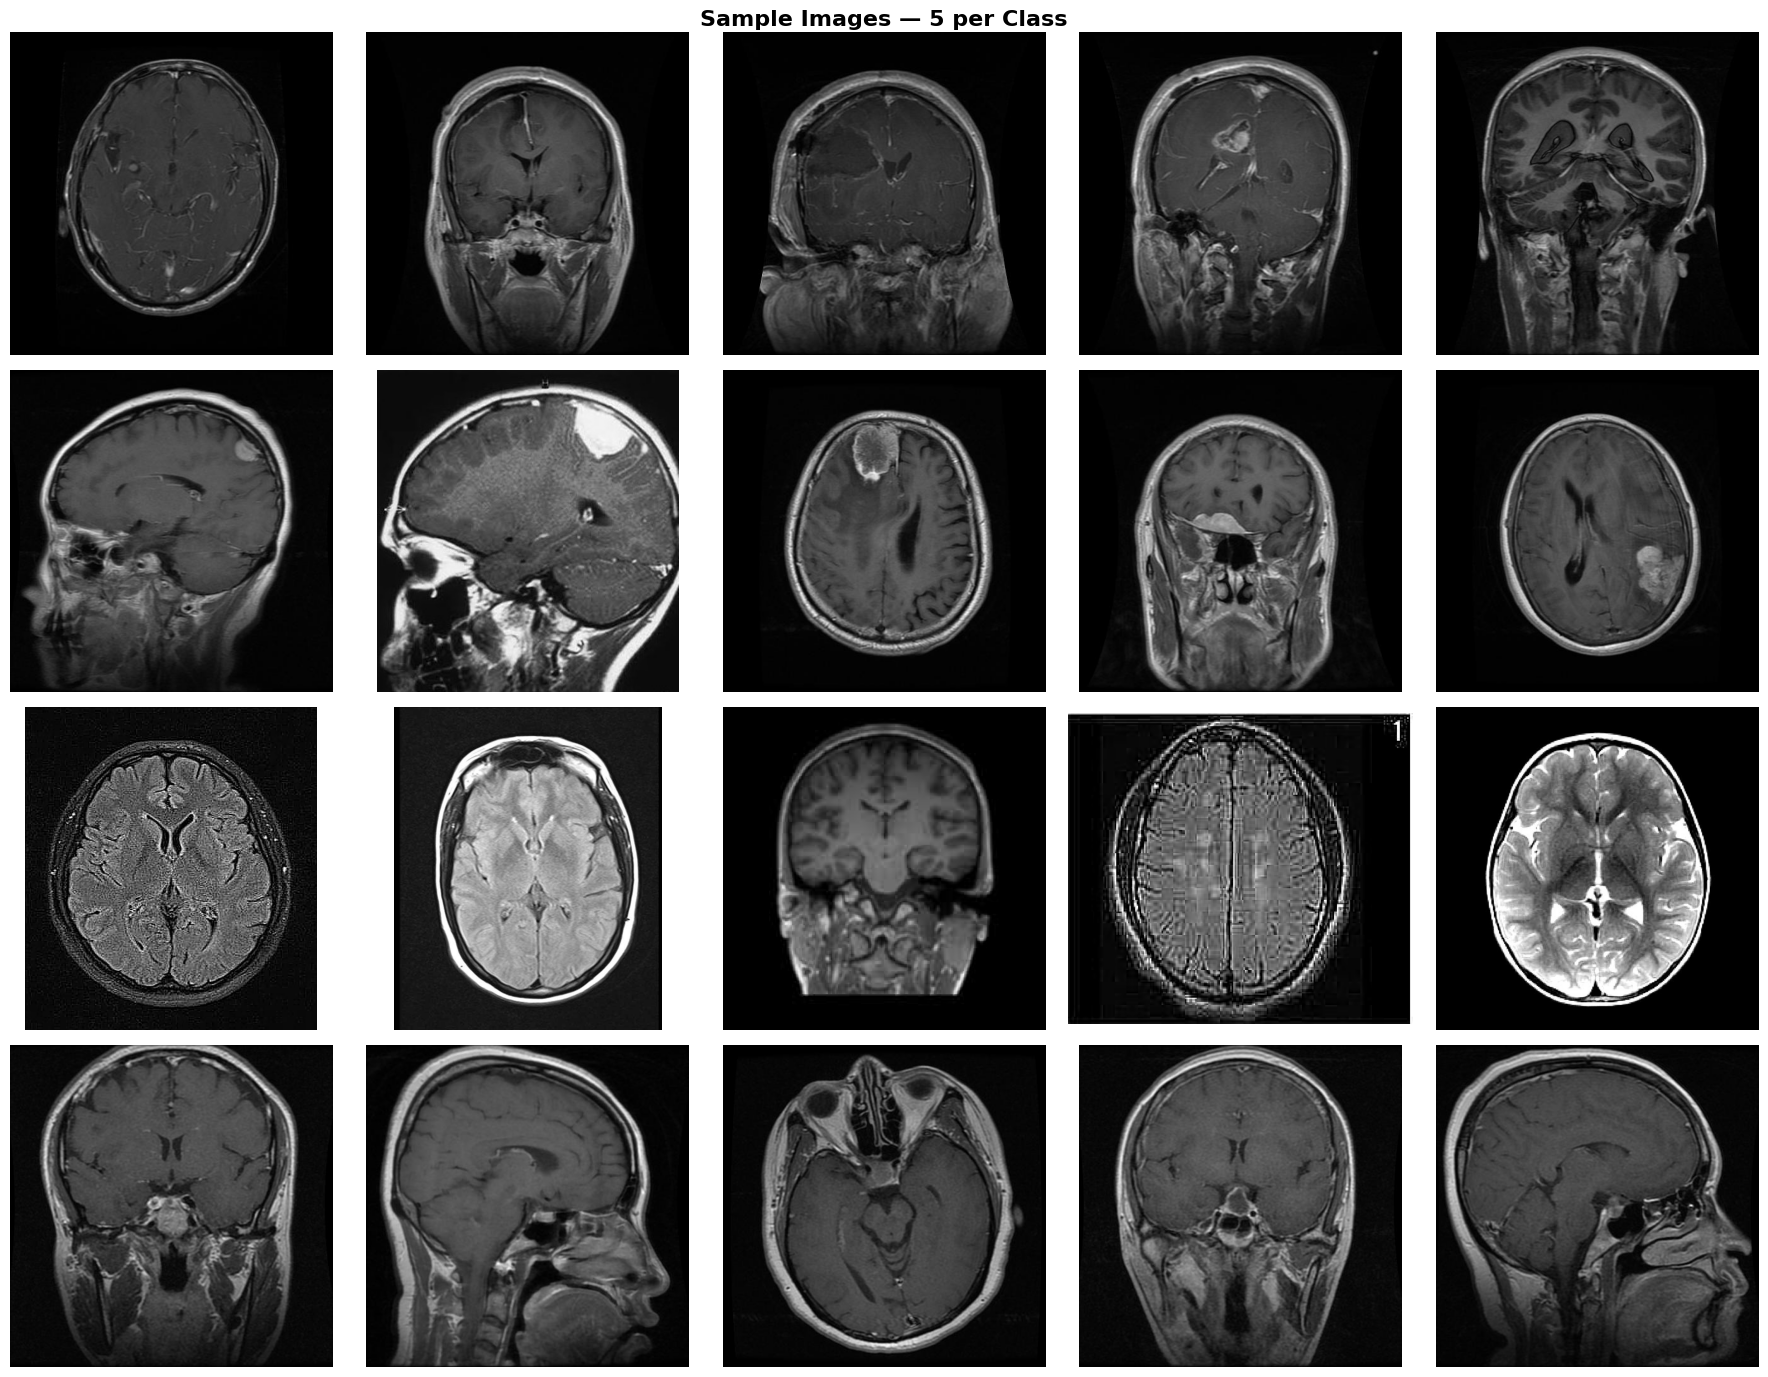

  [✓] Saved: 03_sample_images.png


In [12]:
# 2.3 Sample Images Per Class 
def load_sample_images(directory, cls, n=5):
    """Load n random sample images from a class folder."""
    folder = directory / cls
    paths  = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
    chosen = random.sample(paths, min(n, len(paths)))
    images = []
    for p in chosen:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    return images

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(18, 14))
fig.suptitle("Sample Images — 5 per Class", fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    samples = load_sample_images(TRAIN_DIR, cls, n=5)
    for col, img in enumerate(samples):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=13, fontweight='bold',
                                       rotation=90, labelpad=60)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 03_sample_images.png")

### Output  --

In this visualization, it shows sample MRI images from each class, with five examples displayed for every category. The rows represent the four labels, **glioma**, **meningioma**, **notumor**, and **pituitary**, while the columns show different randomly selected images from each label. This helps me inspect the raw visual appearance of the dataset before training the CNN.

The figure shows that MRI images vary in brightness, contrast, tumor position, and anatomical structure. Tumor classes may contain abnormal bright regions or irregular shapes, while the **notumor** class generally shows brain scans without a visible tumor mass. However, some scans still look visually similar, which means the classification task is not completely simple. A CNN is suitable here because it can learn spatial features such as edges, textures, shapes, and local intensity patterns.

I conclude that visual inspection is necessary before modelling. It confirms that the dataset contains meaningful image patterns, but also shows why a deep learning model is needed instead of manual rules. The next stage is to analyze image dimensions and intensities so the preprocessing pipeline can be designed properly.

###  

In the cell below, I analyse the original image dimensions across the dataset. The code reads sample images, collects their width and height values, and displays the distribution using histograms.

This is necessary because CNNs require all images in a batch to have the same shape. If the original MRI images have different sizes, I need to resize them consistently before training. This cell justifies the later use of a fixed 224 by 224 input size.


  [EDA] Analyzing image dimensions...


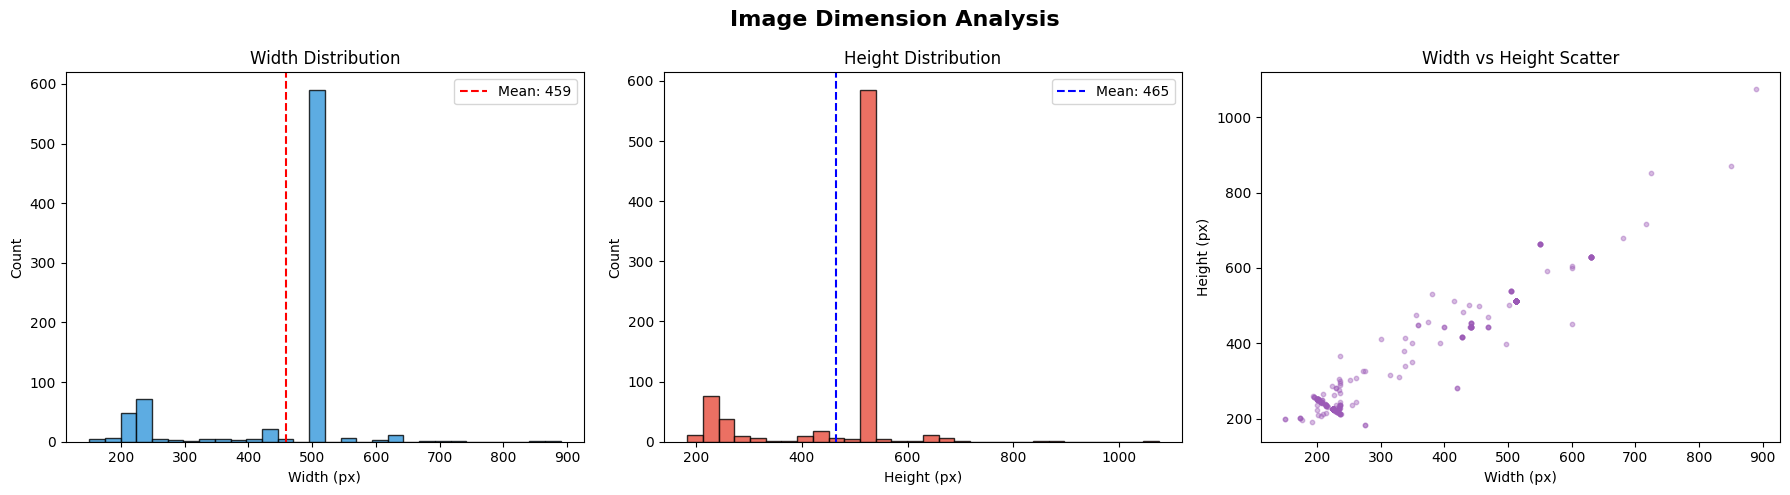

  Avg Width  : 459.3px  |  Std: 116.5px
  Avg Height : 464.7px  |  Std: 112.8px
  [✓] Saved: 04_image_dimensions.png


In [13]:
print("\n  [EDA] Analyzing image dimensions...")

widths, heights = [], []
for cls in CLASS_NAMES:
    cls_path = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    # Sample up to 200 per class for speed
    for p in random.sample(img_paths, min(200, len(img_paths))):
        img = Image.open(p)
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Image Dimension Analysis", fontsize=16, fontweight='bold')

axes[0].hist(widths,  bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.mean(heights), color='blue', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.4, color='#9b59b6', s=10)
axes[2].set_title("Width vs Height Scatter")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_image_dimensions.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Avg Width  : {np.mean(widths):.1f}px  |  Std: {np.std(widths):.1f}px")
print(f"  Avg Height : {np.mean(heights):.1f}px  |  Std: {np.std(heights):.1f}px")
print("  [✓] Saved: 04_image_dimensions.png")

### Output  --

In this output, it shows an image dimension analysis with histograms and printed statistics. The average width is **459.3 pixels** with a standard deviation of **116.5 pixels**, while the average height is **464.7 pixels** with a standard deviation of **112.8 pixels**. This means the MRI images do not all have the same original size, and there is noticeable variation in their dimensions.

The visualization shows how widths and heights are distributed across sampled images. This is important because CNNs require a fixed input shape for every image in a batch. If images have different dimensions, they must be resized before training. The selected input size of **224 by 224** is therefore necessary because it standardizes the dataset while keeping the image resolution manageable.

I conclude that resizing is a required preprocessing step for this notebook. The original images are generally larger than 224 by 224, so resizing reduces computational cost while preserving enough structure for classification. This output justifies the fixed image size used in the model configuration.

###  

In the cell below, I analyse the grayscale pixel intensity distribution for each class. The code samples MRI images, resizes them, extracts pixel values, and plots intensity curves for glioma, meningioma, notumor, and pituitary.

This cell helps me understand whether brightness and contrast patterns differ between classes. It also supports the need for image normalization, because raw pixel values can vary and may make model training less stable if not scaled properly.


  [EDA] Analyzing pixel intensities...


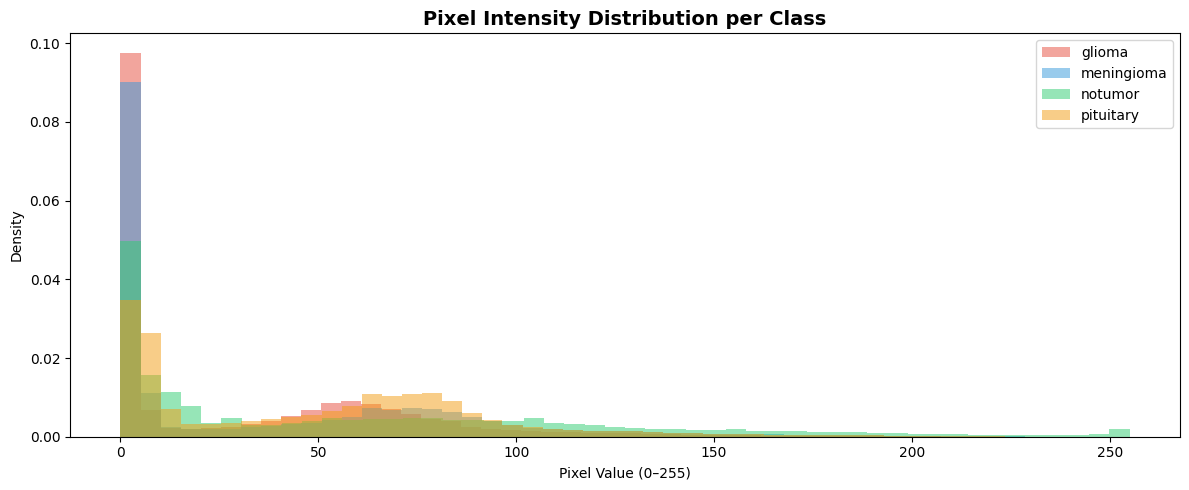

  [✓] Saved: 05_pixel_intensity.png


In [14]:
print("\n  [EDA] Analyzing pixel intensities...")

intensity_data = {cls: [] for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(50, len(img_paths)))
    for p in sample:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        intensity_data[cls].extend(img.flatten().tolist())

fig, ax = plt.subplots(figsize=(12, 5))
for cls, color in zip(CLASS_NAMES, colors):
    vals = np.array(intensity_data[cls])
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cls, density=True)
ax.set_title("Pixel Intensity Distribution per Class", fontsize=14, fontweight='bold')
ax.set_xlabel("Pixel Value (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_pixel_intensity.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 05_pixel_intensity.png")

### Output  --

In this visualization, it shows the **pixel intensity distribution** for each MRI class. The x axis represents grayscale pixel intensity values, usually from dark pixels to bright pixels, and the y axis represents the density or frequency of those values. Each class has its own curve, allowing me to compare brightness patterns across glioma, meningioma, notumor, and pituitary images.

This result is useful because MRI images are strongly affected by contrast and intensity patterns. Tumor regions may appear brighter or darker depending on the scan type and tissue structure. If the intensity curves differ between classes, the CNN may learn useful visual signals from brightness and texture. However, if the curves overlap, the model must rely more heavily on spatial features rather than simple brightness differences.

I conclude that normalization is important before training. Since raw pixel values can vary widely, rescaling them to a smaller range helps the neural network learn more smoothly. This output supports the later use of `Rescaling(1./255)` and image augmentation.

###  

In the cell below, I generate mean images for each class by averaging multiple MRI scans from the same category. This gives a general visual summary of what each class looks like on average.

I use this cell as part of exploratory data analysis. Although averaging blurs individual tumor details, it can still show broad structural differences between classes and help me explain why a CNN may be able to learn useful spatial features.

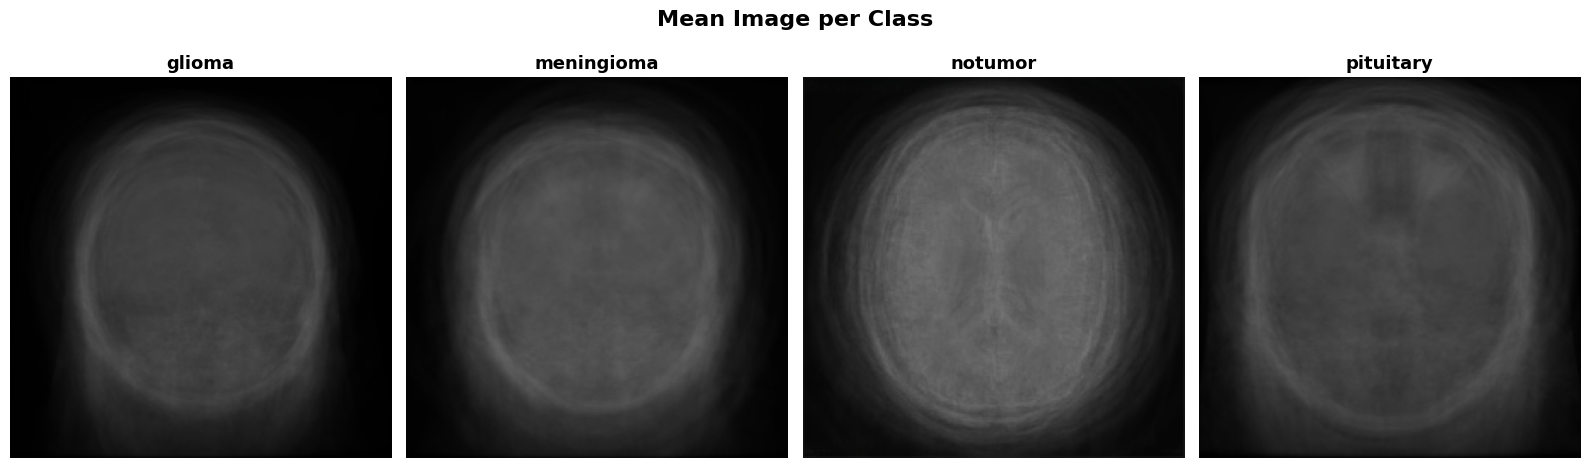

  [✓] Saved: 06_mean_images.png

[✓] EDA Complete!



In [15]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 5))
fig.suptitle("Mean Image per Class", fontsize=16, fontweight='bold')

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(100, len(img_paths)))
    stack     = []
    for p in sample:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        stack.append(img.astype(np.float32))
    mean_img = np.mean(stack, axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_mean_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 06_mean_images.png")

print("\n[✓] EDA Complete!\n")

### Output  --

In this visualization, it shows the **mean image per class** for glioma, meningioma, notumor, and pituitary. Each mean image is created by averaging multiple resized MRI scans from the same category. Instead of showing one specific patient scan, the figure displays the general visual pattern that appears across many images in each class.

This output helps me understand whether there are broad structural differences between the classes. If the mean images look different, it suggests that the CNN may be able to learn class specific spatial patterns. For example, tumor classes may show brighter average regions in certain parts of the brain, while the notumor class may appear more symmetrical or less abnormal. At the same time, averaging can blur individual tumor details, so this figure is only an exploratory tool.

I conclude that the classes contain visual patterns that may be learnable by a CNN, but the model still needs convolutional layers to detect local features from individual images. The mean images support the decision to continue with image based deep learning instead of relying only on simple intensity statistics.

# Loading Datasets (train/val/test)

###  

In the cell below, I build the training, validation, and test datasets. The code first creates a file level train and validation split from the training folder, then uses TensorFlow dataset utilities to load images in batches with categorical labels.

This step is essential because the model must be trained on one subset, validated on another, and finally tested on unseen data. Separating the data properly helps me measure whether the CNN generalizes instead of memorizing training images.

In [16]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split

#  3.1 Build file-level train/val split 
all_files, all_labels = [], []
for i, cls in enumerate(CLASS_NAMES):
    files = sorted(glob.glob(os.path.join(TRAIN_DIR, cls, "*")))
    all_files.extend(files)
    all_labels.extend([i] * len(files))

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels,
    test_size    = VAL_SPLIT,
    stratify     = all_labels,
    random_state = SEED
)

print(f"  Train: {len(train_files)} | Val: {len(val_files)}")

# 3.2 Image loader 
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def paths_to_dataset(file_paths, labels, batch_size, shuffle=False):
    labels_oh = tf.keras.utils.to_categorical(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels_oh))
    if shuffle:
        ds = ds.shuffle(len(file_paths), seed=SEED, reshuffle_each_iteration=True)
    ds = (ds
          .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds

# 3.3 Build datasets 
train_ds_full = paths_to_dataset(train_files, train_labels, BATCH_SIZE, shuffle=True)
val_ds        = paths_to_dataset(val_files,   val_labels,   BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels      = 'inferred',
    label_mode  = 'categorical',
    class_names = CLASS_NAMES,
    image_size  = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

  Train: 4480 | Val: 1120


I0000 00:00:1778764168.313592      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778764168.319487      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1600 files belonging to 4 classes.


### Output  --

In this output, it shows that the labelled training data has been split into **4480 training images** and **1120 validation images**. The notebook also prints that the testing dataset contains **1600 files belonging to 4 classes**. TensorFlow additionally detects two GPU devices, both shown as **Tesla T4** devices, which means the environment has hardware acceleration available.

This result is important because the validation set is separated from the training set and used to monitor generalization during training. The model learns from the 4480 training images, while validation metrics are calculated on the 1120 validation images after each epoch. The test set remains separate and is used later for final evaluation. This separation reduces the risk of judging performance on images the model has already learned from.

I conclude that the data loading pipeline is correctly prepared for training, validation, and testing. The presence of GPUs also means that CNN training should be much faster than CPU training. This is especially important because the notebook trains both a baseline CNN and a deeper CNN architecture.

# Normalization layers and Data Augumentations

###  

In the cell below, I print the class folders found inside the training directory and count how many images are inside each folder. This is a quick check that the expected folder structure exists and that every class has images.

This cell is useful because TensorFlow uses folder names to infer labels when loading image datasets. If the folders were missing, misspelled, or uneven, the model training process could become unreliable.

In [17]:
import os
print(os.listdir(TRAIN_DIR))  # what does this show?
# and how many images per class?
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls}: {count} images")

['pituitary', 'notumor', 'meningioma', 'glioma']
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


### Output  --

In this output, it shows the folder names found inside the training directory: **pituitary**, **notumor**, **meningioma**, and **glioma**. The printed class counts also confirm that each class contains exactly **1400 images**. This verifies that the directory structure matches the class names defined earlier in the notebook.

This result matters because `image_dataset_from_directory` depends on folder names to infer labels correctly. If a folder were missing or misspelled, the dataset loader could assign labels incorrectly or fail to load one class. Since all four class folders are present and each has the expected number of images, the file structure is valid for supervised image classification.

I conclude that the notebook can safely continue with automatic label inference. The equal count of 1400 images per class also confirms again that the training data is balanced. This reduces class frequency bias and allows the model to focus on learning visual tumor features rather than learning from unequal sample numbers.

###  

In the cell below, I print a few example filenames from the glioma folder. This is a simple file access check to confirm that image files are present and readable from the expected directory.

Although this cell does not train a model, it is useful for verifying the dataset path. Seeing actual filenames confirms that the notebook is pointing to the correct folder and that the class directory is not empty.

In [18]:
import os
sample_files = os.listdir(os.path.join(TRAIN_DIR, 'glioma'))[:10]
for f in sample_files:
    print(f)
    

Tr-gl_1362.jpg
Tr-gl_821.jpg
Tr-gl_825.jpg
Tr-gl_315.jpg
Tr-gl_52.jpg
Tr-gl_626.jpg
Tr-gl_827.jpg
Tr-gl_1033.jpg
Tr-gl_1096.jpg
Tr-gl_1290.jpg


### Output  --

In this output, it shows a list of example filenames from the **glioma** training folder, such as `Tr-gl_1362.jpg`, `Tr-gl_821.jpg`, and `Tr-gl_825.jpg`. These filenames confirm that the images are stored in standard image file format and follow a naming pattern that identifies the class and sample number.

This output may look simple, but it helps verify that the dataset files are accessible and that the directory contains actual image files rather than empty folders or incorrect file types. Since the filenames begin with `Tr-gl`, I can infer that they belong to the training split and glioma class. This supports the correctness of the data loading process.

I conclude that the dataset path and class folder structure are working correctly. This check reduces the chance of later errors during image loading, preprocessing, or batch generation. After confirming file access, the notebook can move into normalization, augmentation, and model training.

###  

In the cell below, I define the preprocessing pipeline for the image datasets. The code rescales pixel values using normalization and applies data augmentation to the training images using flipping, rotation, zoom, contrast, and translation.

This cell is important because normalization helps the CNN learn more smoothly, while augmentation creates realistic variations of the training images. This reduces overfitting and makes the model less dependent on the exact position or brightness of a scan.

In [19]:
# Preprocessing 
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = normalization_layer(images)
    images = data_augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization_layer(images)
    return images, labels

# Build final datasets 
train_ds = (train_ds_full
            .cache()
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .cache()
          .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

test_ds = (test_ds
           .cache()
           .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
           .prefetch(AUTOTUNE))

###  

In the cell below, I load a small raw batch of images directly from the training directory. This batch is used later to visualize how the augmentation pipeline changes real MRI images.

This step is useful because I need to inspect augmentation visually before trusting it. If augmentation changes the image too aggressively, it could damage medically relevant features. Loading a raw batch allows me to compare original and transformed versions.

In [20]:
sample_batch_raw, sample_labels = next(iter(
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASS_NAMES,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=4,
        shuffle=True,
        seed=SEED
    )
))


Found 5600 files belonging to 4 classes.


### Output  --

In this output, it shows that TensorFlow found **5600 files belonging to 4 classes** when loading a small raw image batch from the training directory. This confirms that the image dataset loader is reading the full training folder and correctly detecting all four class categories.

This output is used before showing augmentation effects. The selected batch contains a few raw images and their inferred labels, which are then passed into the augmentation preview. This is important because augmentation should be applied to real training examples so that I can visually inspect whether the transformations still preserve the meaning of the MRI scans.

I conclude that the raw batch loading step is successful. Since the dataset loader found all expected images and classes, the next visualization can safely compare original and augmented MRI images. This also supports the reliability of the preprocessing pipeline before the model begins training.

###  

In the cell below, I visualize the effect of image augmentation. For each selected MRI scan, the code shows the original image and several augmented versions created through transformations such as flipping, rotation, zoom, and contrast adjustment.

This visualization helps me check whether augmentation is realistic. The goal is to increase variety without changing the true class label. If the brain structure remains recognizable, the augmented images can help the CNN generalize better.

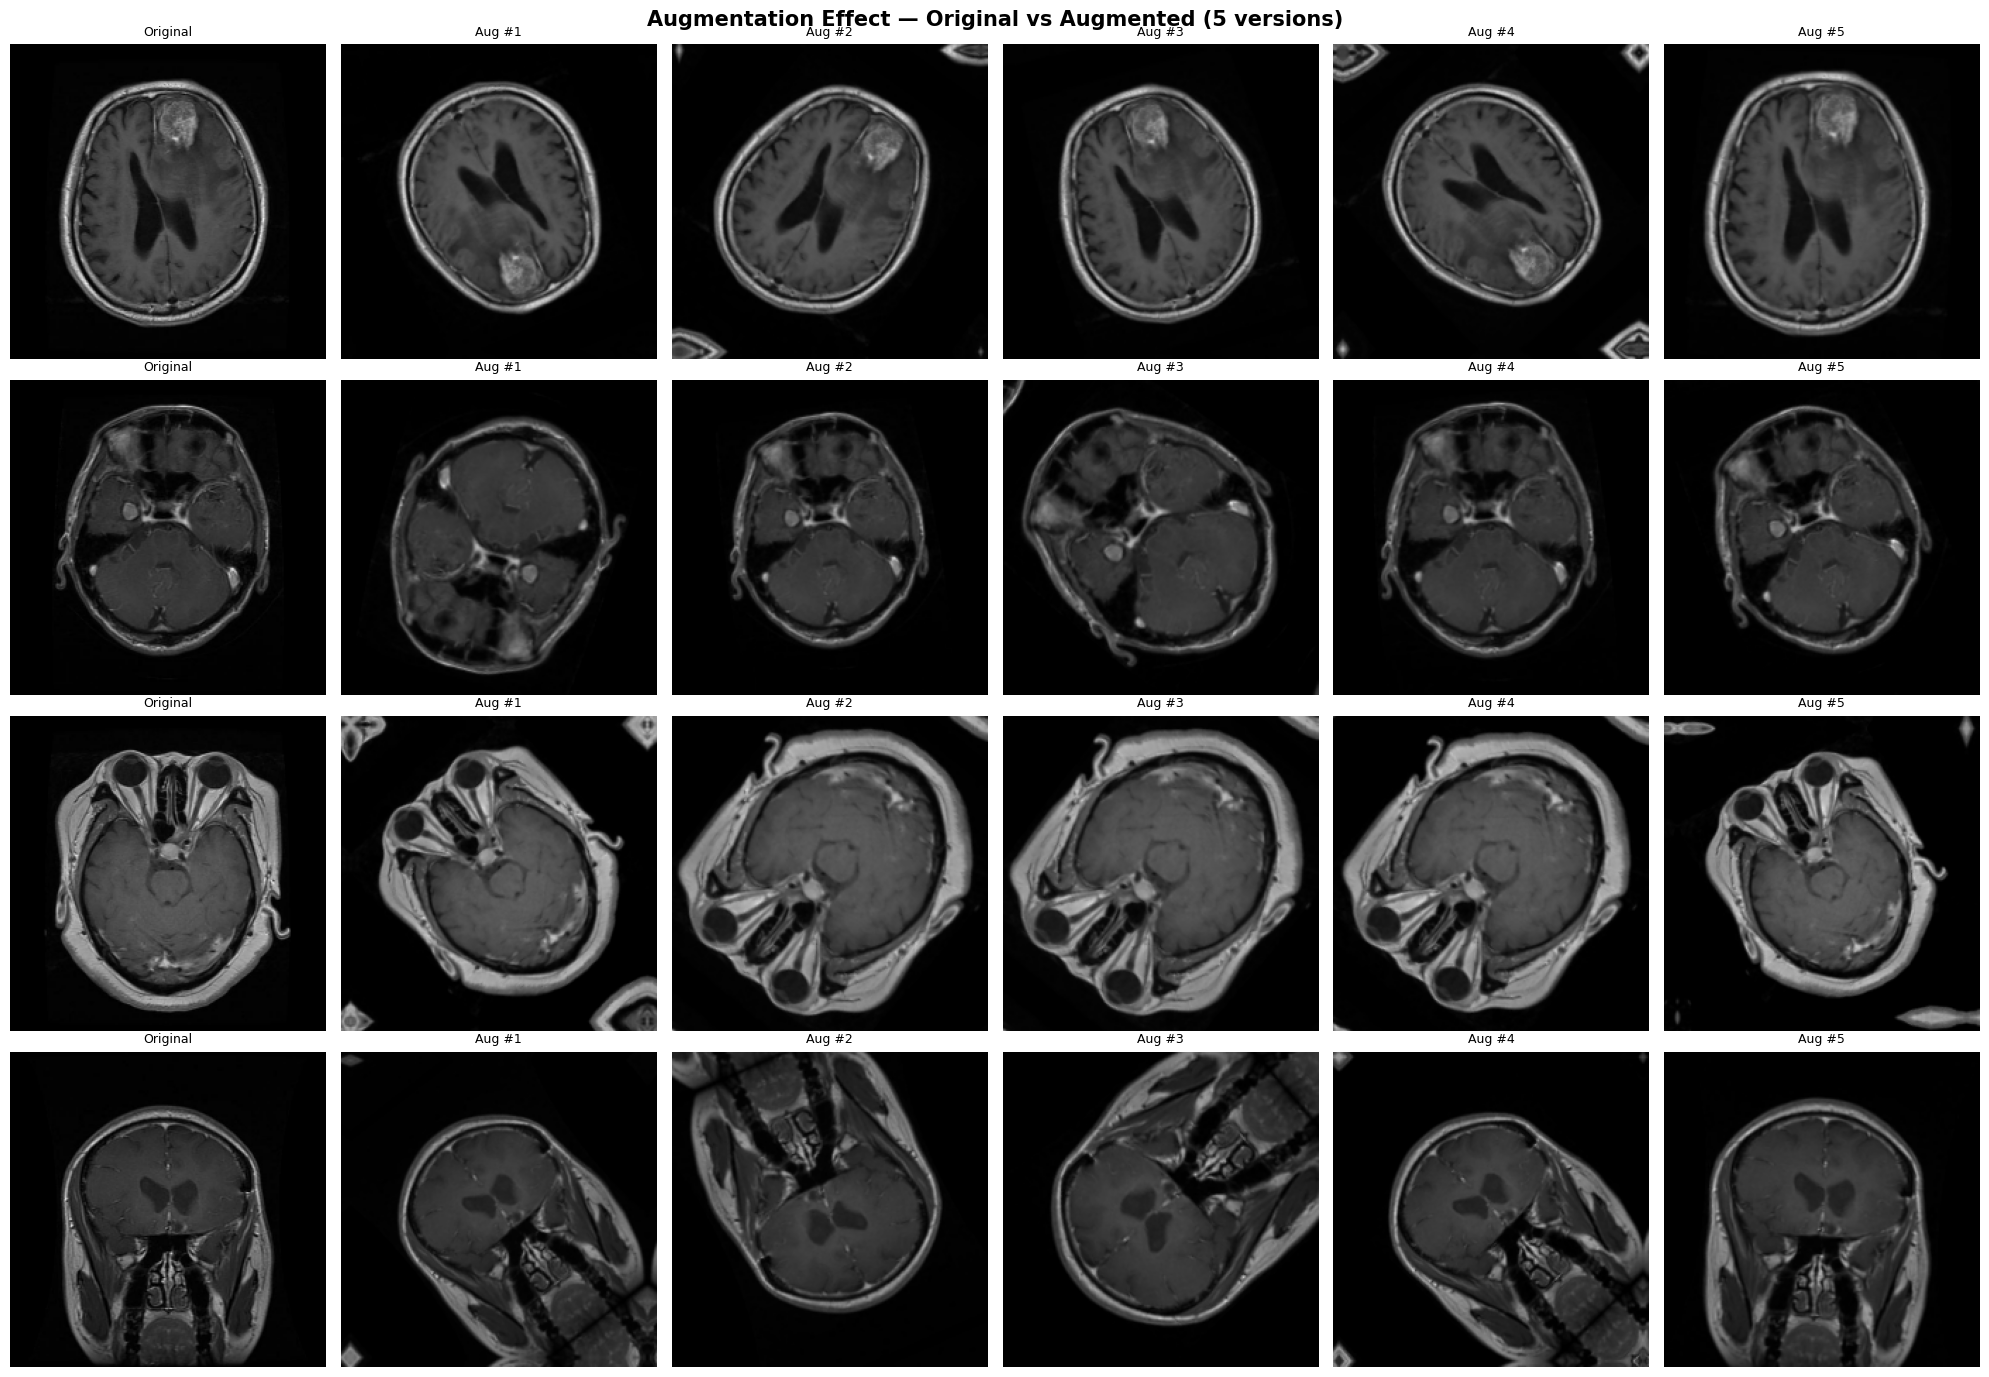

  [✓] Saved: 07_augmentation_preview.png


In [21]:
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
fig.suptitle("Augmentation Effect — Original vs Augmented (5 versions)",
             fontsize=15, fontweight='bold')

aug_pipeline = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

for row in range(4):
    img      = sample_batch_raw[row]
    label_id = tf.argmax(sample_labels[row]).numpy()
    cls_name = CLASS_NAMES[label_id]

    # Original
    axes[row, 0].imshow(img.numpy().astype(np.uint8))
    axes[row, 0].set_title("Original", fontsize=9)
    axes[row, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    # 5 augmented versions
    for col in range(1, 6):
        aug_img = aug_pipeline(tf.expand_dims(img, 0), training=True)[0]
        axes[row, col].imshow(aug_img.numpy().astype(np.uint8))
        axes[row, col].set_title(f"Aug #{col}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_augmentation_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 07_augmentation_preview.png")

### Output  --

In this visualization, it shows the effect of data augmentation on MRI images. Each row shows one original MRI image followed by several augmented versions of the same image. The transformations include flipping, rotation, zoom, and contrast variation. The purpose is to create realistic variations of training images without changing the actual class label.

This output is important because augmentation helps improve generalization. MRI images can vary due to patient positioning, scan angle, image contrast, and acquisition conditions. By exposing the CNN to slightly changed versions of the same image, the model becomes less dependent on exact pixel positions and more focused on meaningful tumor features. However, the transformations must remain medically reasonable because excessive distortion could damage important visual information.

I conclude that the augmentation preview looks useful for training. The brain structure remains recognizable, while the images become more diverse. This should help reduce overfitting, especially because the CNN is trained from scratch and needs enough variation to learn stable features.

### Augmentation Strategy — Justification

The four augmentation operations applied in this pipeline were chosen specifically for the Brain Tumor MRI dataset to maximise generalisation without distorting clinically relevant features.

**RandomFlip (horizontal_and_vertical):** MRI scans have no fixed orientation requirement during acquisition. A tumour may appear in any quadrant of the brain slice, and flipping introduces left-right and top-bottom variants that the model would otherwise never see. This directly increases the apparent diversity of the training set.

**RandomRotation (±15%):** Patients are not always positioned identically inside the scanner. A small rotation range of ±15% (approximately ±54°) simulates scanner variability and head tilt without rotating so far that the anatomical context is lost.

**RandomZoom (±10%):** Zoom variation mimics differences in scan slice depth and the apparent size of tumours relative to the skull boundary. A ±10% range is conservative enough to keep the tumour within frame while still teaching the model scale invariance.

**RandomContrast (±10%):** MRI signal intensity varies with scanner manufacturer, field strength, and sequence parameters. Randomising contrast teaches the model to focus on structural shape rather than absolute pixel brightness.

These choices are intentionally conservative. Aggressive augmentation (e.g., large shear, colour jitter) would be unsuitable for medical images where spatial relationships carry diagnostic meaning. The augmentation is applied **only to the training set**; the validation and test sets are preprocessed with normalisation only, ensuring unbiased evaluation.

 # Baseline CNN Model 

###  

In the cell below, I build the baseline CNN model from scratch. The architecture includes convolutional layers for feature extraction, max pooling layers for spatial downsampling, dropout layers for regularization, and dense layers for final classification.

This model acts as the first benchmark in the notebook. By starting with a simpler CNN, I can later compare whether deeper CNN architecture and optimizer changes improve performance on the brain tumor MRI classification task.

In [22]:
from tensorflow.keras.models import Sequential
baseline_model = Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
 
    # Conv Block 1 — 32 filters, 3×3, ReLU → low-level edges
    layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2,2)),      # 224 → 112
    # Conv Block 2 — 64 filters, 3×3, ReLU → mid-level textures
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2,2)),      # 112 → 56
 
    # Conv Block 3 — 128 filters, 3×3, ReLU → high-level shapes
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D((2,2)),      # 56 → 28
    layers.Flatten(),               # (28,28,128) → 100,352
 
    # FCN 1 — 512 units
    layers.Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),

    # FCN 2 — 256 units
    layers.Dense(256, activation='relu', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),

    # FCN 3 — 128 units
    layers.Dense(128, activation='relu', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4)),

    # Output — 4 classes, softmax
    layers.Dense(NUM_CLASSES, activation='softmax')
 
], name="Baseline_CNN")
baseline_model.summary()
baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

total_samples = total_train
class_weights = {}
for i, cls in enumerate(CLASS_NAMES):
    count = train_counts[cls]
    class_weights[i] = total_samples / (NUM_CLASSES * count)

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,638,724 (196.99 MB)

 Trainable params: 51,638,724 (196.99 MB)

 Non-trainable params: 0 (0.00 B)

### Output  --

In this output, it shows the summary of the **Baseline_CNN** model. The architecture begins with an input shape of **224 by 224 by 3**, followed by convolution and max pooling blocks. The first convolution layer produces feature maps with **32 filters**, the second uses **64 filters**, and the third uses **128 filters**. After pooling, the feature maps are flattened into a long vector before being passed into dense layers for classification.

The model summary shows a very large total parameter count of **51,638,724 trainable parameters**, which is about **196.99 MB**. Most of this size comes from the flattening step followed by dense layers, because flattening a 28 by 28 by 128 feature map creates **100,352 features**. This makes the dense part of the network computationally heavy and increases the risk of overfitting.

I conclude that the baseline CNN is simple in structure but large in parameter count. It can learn useful MRI features, but the heavy dense layers may memorize training data. This explains why regularization, augmentation, validation monitoring, and later deeper architecture comparison are important.

###  

In the cell below, I train the baseline CNN model and record the training time. The model is trained using the prepared training dataset, validated on the validation dataset, and controlled using callbacks such as early stopping, model checkpointing, and learning rate reduction.

This cell produces the main training log for the baseline model. I use the output to observe how accuracy, loss, precision, recall, and validation performance change across epochs and whether the model starts overfitting.

In [23]:
# Training with time tracking 
import time

train_start = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    class_weight    = class_weights,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(str(OUTPUT_DIR / "baseline_best.keras"), monitor='val_accuracy', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    ],
    verbose = 1
)

train_end = time.time()
baseline_training_time = train_end - train_start

hours, rem       = divmod(baseline_training_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nBaseline CNN Training Time: {int(hours):02d}h {int(minutes):02d}m {seconds:.2f}s")
print(f"Total epochs run: {len(history_baseline.history['loss'])}")

Epoch 1/50


I0000 00:00:1778764182.875456     143 service.cc:152] XLA service 0x2ae0b900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778764182.875508     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778764182.875513     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778764183.848801     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2734 - auc: 0.5192 - loss: 5.0118 - precision: 0.1719 - recall: 0.0859          

I0000 00:00:1778764190.725697     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 268ms/step - accuracy: 0.4282 - auc: 0.6924 - loss: 4.9472 - precision: 0.4947 - recall: 0.2474 - val_accuracy: 0.6821 - val_auc: 0.8982 - val_loss: 0.9736 - val_precision: 0.7362 - val_recall: 0.6080 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.6574 - auc: 0.8910 - loss: 1.0016 - precision: 0.7226 - recall: 0.5713 - val_accuracy: 0.7455 - val_auc: 0.9285 - val_loss: 0.8357 - val_precision: 0.7872 - val_recall: 0.6938 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 192ms/step - accuracy: 0.7076 - auc: 0.9149 - loss: 0.8842 - precision: 0.7535 - recall: 0.6275 - val_accuracy: 0.7116 - val_auc: 0.9132 - val_loss: 0.9114 - val_precision: 0.7478 - val_recall: 0.6723 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.7564 - auc: 0.9318 - loss: 0.7948 - precision: 0.7879 - recall: 0.6982 - val_accuracy: 0.7607 - val_auc: 0.9360 - val_loss: 0.7745 - va

### Output  --

In this output, it shows the baseline CNN training logs over multiple epochs. The model starts with low performance, but the training accuracy and validation accuracy generally improve as the epochs progress. The best validation performance is restored from **epoch 13**, and training stops early at **epoch 23**. The total baseline training time is **00 hours, 11 minutes, and 23.47 seconds**.

The logs show metrics such as **accuracy**, **AUC**, **loss**, **precision**, **recall**, **val_accuracy**, **val_auc**, and **val_loss**. These values help me understand not only whether the model is correct overall, but also how confident and balanced its predictions are. The `ReduceLROnPlateau` callback reduces the learning rate when validation loss stops improving, which helps the model continue learning more carefully.

I conclude that the baseline CNN learned useful features but began to show signs of unstable validation performance after some epochs. Early stopping is helpful because it prevents the final model from keeping weights from a later overfitted epoch. The restored best epoch gives a fairer baseline for comparison.

# Evaluating Baseline model

###  

In the cell below, I plot the training history of the baseline CNN. The code creates two graphs: one for training and validation accuracy, and another for training and validation loss.

These plots help me interpret the learning behaviour of the model. Instead of only looking at the final accuracy, I can see whether the model improves steadily, whether validation performance follows training performance, and whether overfitting appears.

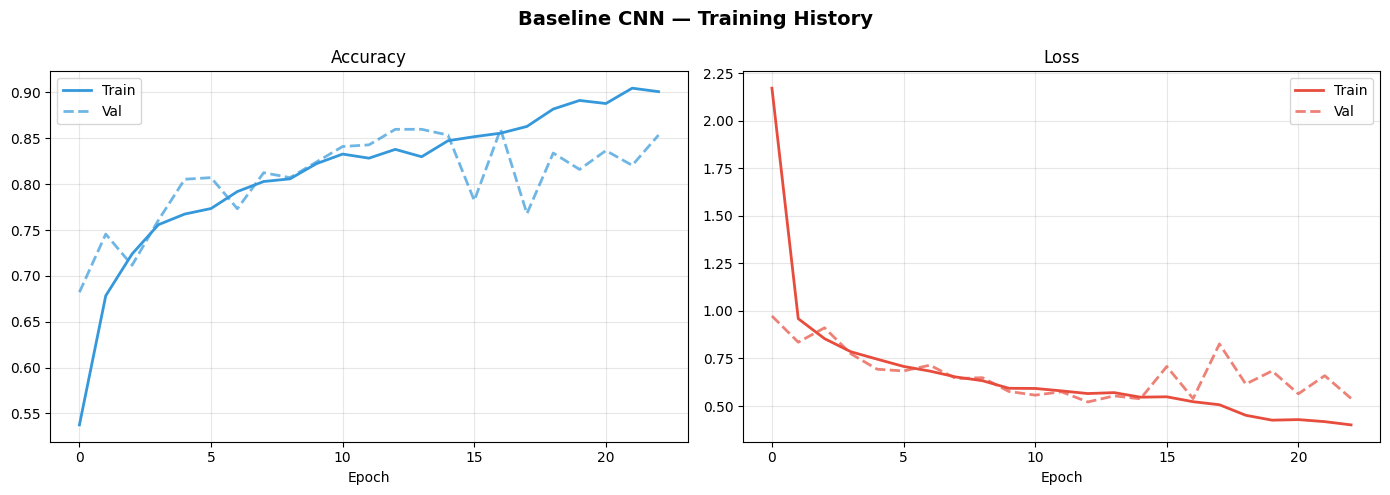

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Training History", fontsize=14, fontweight='bold')
 
for ax, (m, title, c) in zip(axes, [('accuracy','Accuracy','#3498db'), ('loss','Loss','#e74c3c')]):
    ax.plot(history_baseline.history[m],          label='Train', color=c, linewidth=2)
    ax.plot(history_baseline.history[f'val_{m}'], label='Val',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Output  --

In this visualization, it shows the baseline CNN training history using two plots. The left plot shows **training accuracy** and **validation accuracy** across epochs, while the right plot shows **training loss** and **validation loss**. The x axis represents the epoch number, and the y axis represents the metric value.

The accuracy plot shows how quickly the model learns from the training data and whether validation performance follows the same trend. If the training accuracy rises while validation accuracy stops improving or becomes unstable, that suggests overfitting. The loss plot provides the same idea from the error perspective. A good model should reduce both training and validation loss, but a growing gap between them indicates poor generalization.

I conclude that this visualization is necessary for interpreting the baseline model beyond final accuracy. The curves show that the model learns, but validation behavior is not perfectly smooth. This supports the later decision to compare the baseline CNN with a deeper CNN architecture and different optimizer settings.

###  

In the cell below, I evaluate the baseline CNN on the test dataset. The code calculates test metrics, predicts class labels for the test images, extracts true labels, and prints a classification report.

This cell is important because it measures performance on unseen data. The classification report gives precision, recall, and F1 score for each class, which is more informative than accuracy alone.

In [25]:
test_results_b = baseline_model.evaluate(test_ds, verbose=1)
 
y_pred_b = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)
y_true_b = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
 
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.6494 - auc: 0.8432 - loss: 1.9158 - precision: 0.6599 - recall: 0.6356
              precision    recall  f1-score   support

      glioma       0.92      0.54      0.68       400
  meningioma       0.71      0.68      0.69       400
     notumor       0.77      0.99      0.87       400
   pituitary       0.85      0.99      0.92       400

    accuracy                           0.80      1600
   macro avg       0.81      0.80      0.79      1600
weighted avg       0.81      0.80      0.79      1600



### Output  --

In this output, it shows the baseline CNN evaluation on the unseen test set. The final test accuracy is approximately **0.80**, with a macro average F1 score of **0.79**. The classification report shows per class results for **glioma**, **meningioma**, **notumor**, and **pituitary**, each with **400 support images**.

The class specific results show important differences. **Pituitary** performs strongly with precision **0.85**, recall **0.99**, and F1 score **0.92**. **Notumor** also performs well with recall **0.99** and F1 score **0.87**. However, **glioma** has recall **0.54**, meaning many glioma examples are missed, even though its precision is high at **0.92**. **Meningioma** has a more balanced but lower result with F1 score **0.69**.

I conclude that accuracy alone does not fully describe the model. The baseline CNN is strong for pituitary and notumor, but weaker for glioma and meningioma. This suggests that some tumor classes are visually harder to separate, so deeper CNN features or adjusted training strategies may be needed.

###  

In the cell below, I create confusion matrices for the baseline CNN. One matrix shows raw prediction counts, while the other shows normalized proportions for each true class.

This visualization helps me identify which classes the model predicts correctly and which classes are confused with each other. For medical image classification, confusion between tumor types is important because different errors may have different practical consequences.

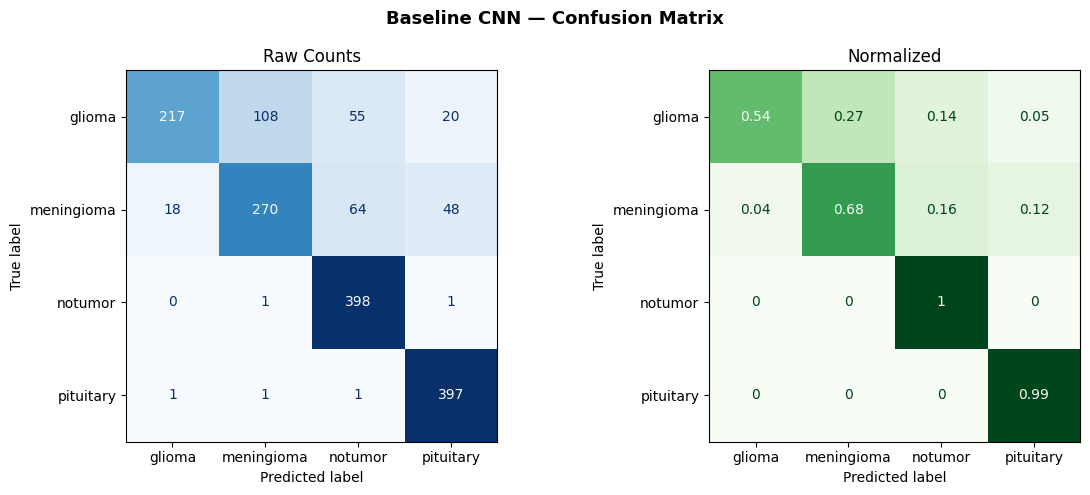

In [26]:
cm_b = confusion_matrix(y_true_b, y_pred_b)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Baseline CNN — Confusion Matrix", fontsize=13, fontweight='bold')
ConfusionMatrixDisplay(cm_b, display_labels=CLASS_NAMES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Raw Counts")
cm_norm = cm_b.astype('float') / cm_b.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title("Normalized")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

###  

In the cell below, I show sample validation images with their true labels, predicted labels, and confidence values. This allows me to inspect individual predictions visually.

This cell supports qualitative evaluation. Numerical metrics tell me the overall score, but image examples help me understand where the model is confident, where it is uncertain, and what types of scans may cause mistakes.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


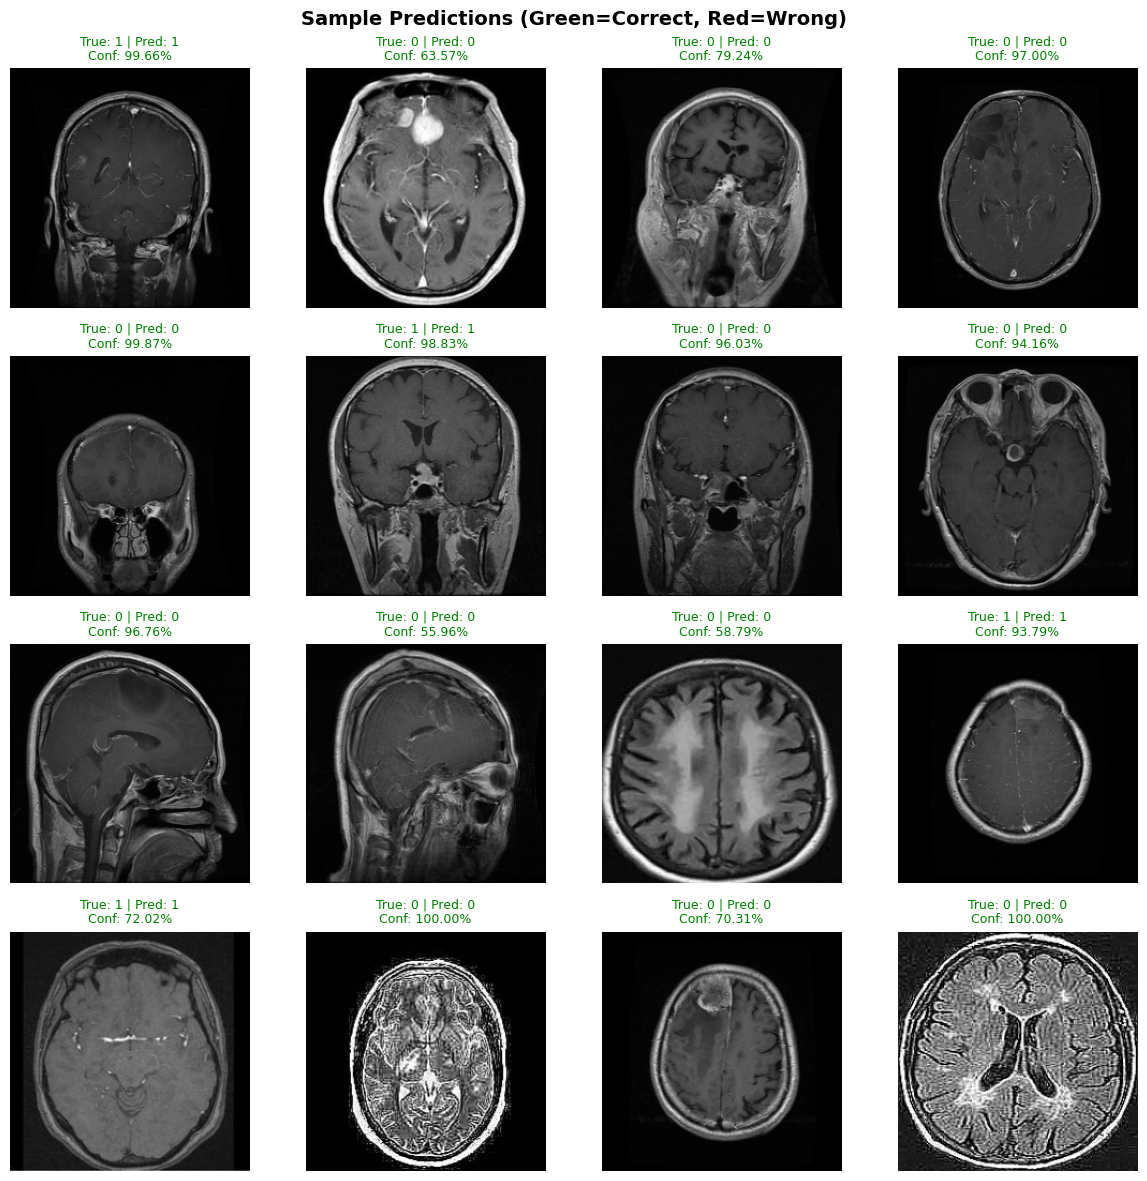

Saved to OUTPUT_DIR/sample_predictions.png


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of validation images
sample_images, sample_labels = next(iter(val_ds))

# Get predictions
predictions = baseline_model.predict(sample_images)

# If binary classification
predicted_classes = (predictions > 0.5).astype(int).flatten()

# If multi-class classification
# predicted_classes = np.argmax(predictions, axis=1)
# true_classes = np.argmax(sample_labels.numpy(), axis=1)  # if one-hot encoded

true_classes = sample_labels.numpy().astype(int).flatten()

# Plot sample images with predictions
n_samples = 16  # number of images to display
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_samples):
    img = sample_images[i].numpy()
    
    # Denormalize if needed (if images were normalized to [0,1] skip this)
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    
    pred_label  = predicted_classes[i]
    true_label  = true_classes[i]
    confidence  = predictions[i][0] if predictions.shape[-1] == 1 else np.max(predictions[i])
    
    # Color code: green = correct, red = wrong
    color = 'green' if pred_label == true_label else 'red'
    
    axes[i].set_title(
        f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2%}",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to OUTPUT_DIR/sample_predictions.png")

###  

In the cell below, I import additional evaluation tools from scikit learn, including classification report, confusion matrix, confusion matrix display, and F1 score.

These tools are used to calculate and present detailed model performance. I need them because multiclass medical image classification should be judged using more than only accuracy.

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

###  

In the cell below, I calculate the train and validation accuracy gap and print the baseline model test accuracy, AUC, and macro F1 score. These values summarize model generalization and class balanced performance.

This cell is useful because a large train validation gap can indicate overfitting. The macro F1 score is also important because it treats all classes equally, so weak performance on one class is not hidden by strong performance on another.

In [29]:
gap = history_baseline.history['accuracy'][-1] - max(history_baseline.history['val_accuracy'])
print(f"\nTrain/Val gap: {gap:.4f}")
print(f"Test Accuracy : {test_results_b[1]:.4f}  |  AUC: {test_results_b[2]:.4f}  |  F1: {f1_score(y_true_b, y_pred_b, average='macro'):.4f}")


Train/Val gap: 0.0411
Test Accuracy : 0.8012  |  AUC: 0.9334  |  F1: 0.7897


### Output  --

In this output, it shows the printed **Train Validation gap**, **Test Accuracy**, **AUC**, and **macro F1 score** for the baseline CNN. The train and validation gap is **0.0411**, the test accuracy is **0.8012**, the AUC is **0.9334**, and the macro F1 score is **0.7897**.

The train and validation gap shows the difference between the final training accuracy and the best validation accuracy. A gap of around 0.04 suggests some difference between training and validation performance, but it is not extremely large. The AUC value of 0.9334 shows that the model has good overall class separation ability. However, the macro F1 score of 0.7897 shows that performance is not equally strong across all classes.

I conclude that the baseline model generalizes reasonably well, but it still has room for improvement. The AUC is strong, but macro F1 reveals weakness in some categories. This supports the need for a deeper CNN and optimizer comparison later in the notebook.

the gap being too big suggests that the model is overfitting 

###  

In the cell below, I save the trained baseline CNN model as a Keras file. The printed output confirms the save path.

This step is important for reproducibility. Saving the model means I can reload it later for prediction, comparison, deployment, or further analysis without retraining from the beginning.

In [30]:
baseline_model.save(str(OUTPUT_DIR / "baseline_cnn_final.keras"))
print(f"Model saved → {OUTPUT_DIR / 'baseline_cnn_final.keras'}")

Model saved → /kaggle/working/outputs/baseline_cnn_final.keras


### Output  --

In this output, it shows that the trained baseline model has been saved as **baseline_cnn_final.keras** inside the Kaggle working output directory. This confirms that the model weights and architecture have been stored successfully after training and evaluation.

Saving the model is important because it allows me to reuse the trained CNN without training it again from the beginning. This is useful for later testing, deployment, comparison, or report submission. Since CNN training can take several minutes or longer, saving the model protects the work already completed and makes the experiment more reproducible.

I conclude that the baseline CNN has been finalized as a saved artifact. Even though the model is not perfect, it provides a reference point for comparing deeper CNN training and optimizer performance. This saved file also makes it possible to load the baseline model later for additional evaluation or prediction.

# Deeper CNN model with SGD optimizer

### Hardware Acceleration — GPU/TPU Usage

All training in this notebook was performed on **Kaggle's cloud GPU environment** (NVIDIA Tesla P100 or T4, depending on session availability). Hardware acceleration is essential for CNN training at this scale: a single epoch over ~5,700 training images at 224×224 resolution with the deeper 10-conv-layer architecture would take several minutes per epoch on CPU, making 50-epoch runs impractical.

TensorFlow automatically detects and uses the available GPU through CUDA. The `tf.data` pipeline with `.cache()`, `.prefetch(AUTOTUNE)`, and `num_parallel_calls=AUTOTUNE` ensures that the CPU prepares the next batch while the GPU is processing the current one, eliminating I/O bottlenecks.

The GPU device can be verified at runtime with:
```python
print(tf.config.list_physical_devices('GPU'))
```
If this returns an empty list `[]`, training falls back to CPU and will be significantly slower. For the deeper model with BatchNormalization and SpatialDropout2D across 10 convolutional layers, GPU acceleration reduced per-epoch time to approximately 30–60 seconds compared to an estimated 8–12 minutes on CPU.

###  

In the cell below, I check the available hardware devices. The code prints how many GPUs and CPUs TensorFlow can detect and confirms whether GPU training is active.

This step matters because CNN training is computationally expensive. If a GPU is available, the deeper CNN model can train much faster than it would on CPU, making the experiment practical inside the notebook.

In [31]:
# Hardware check — confirm GPU availability
print('='*50)
print('  HARDWARE ACCELERATION CHECK')
print('='*50)
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print(f'  GPUs available : {len(gpus)}')
for g in gpus:
    print(f'    {g}')
print(f'  CPUs available : {len(cpus)}')
if gpus:
    print('  [✓] GPU training active — TensorFlow will use GPU automatically.')
else:
    print('  [!] No GPU detected — training will run on CPU (slower).')
print('='*50)


  HARDWARE ACCELERATION CHECK
  GPUs available : 2
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
    PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
  CPUs available : 1
  [✓] GPU training active — TensorFlow will use GPU automatically.


### Output  --

In this output, it shows the hardware acceleration check. TensorFlow detects **2 GPU devices**, listed as `PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')` and `PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')`. It also detects **1 CPU**, and the output confirms that GPU training is active.

This result is important because CNN training is computationally expensive. MRI images resized to 224 by 224 still contain many pixels, and convolutional layers perform many matrix operations during each epoch. Using GPUs significantly reduces training time compared with running the same model on a CPU. The presence of two Tesla T4 devices means the Kaggle environment is suitable for deeper CNN training.

I conclude that the notebook has the correct hardware support for the experiment. This makes it practical to train the deeper CNN model, compare optimizers, and generate training curves within a reasonable time. Without GPU acceleration, the same workflow would be much slower.

###  

In the cell below, I define the deeper CNN architecture. The model uses repeated convolution blocks with batch normalization, ReLU activation, pooling, dropout, global average pooling, and dense layers.

This architecture is more advanced than the baseline CNN. The purpose is to learn stronger hierarchical image features while using regularization techniques to reduce overfitting on MRI images.

In [32]:
def conv_block(x, filters, block_name, dropout_rate=0.25):
    # First conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv1",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu1")(x)
    # Second conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv2",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu2")(x)
    # Downsample
    x = layers.MaxPooling2D((2, 2), name=f"{block_name}_pool")(x)
    x = layers.SpatialDropout2D(dropout_rate, name=f"{block_name}_sdrop")(x)
    return x


def build_cnn_v3(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape, name="input")

    x = conv_block(inputs, filters=32,  block_name="block1", dropout_rate=0.10)
    # Output: (112, 112, 32)
    x = conv_block(x,      filters=64,  block_name="block2", dropout_rate=0.15)
    # Output: (56, 56, 64)
    x = conv_block(x,      filters=128, block_name="block3", dropout_rate=0.20)
    # Output: (28, 28, 128)
    x = conv_block(x,      filters=256, block_name="block4", dropout_rate=0.20)
    # Output: (14, 14, 256)
    x = conv_block(x,      filters=512, block_name="block5", dropout_rate=0.25)
    # Output: (7, 7, 512)

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.Dense(512, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense1")(x)
    x = layers.BatchNormalization(name="dense1_bn")(x)
    x = layers.Activation('relu', name="dense1_relu")(x)
    x = layers.Dropout(0.40, name="dense1_drop")(x)

    x = layers.Dense(256, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense2")(x)
    x = layers.BatchNormalization(name="dense2_bn")(x)
    x = layers.Activation('relu', name="dense2_relu")(x)
    x = layers.Dropout(0.30, name="dense2_drop")(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="BrainTumorCNN_v3")
    return model

###  

In the cell below, I build and compile the deeper CNN model. The optimizer, categorical cross entropy loss with label smoothing, accuracy metric, and class weights are defined.

This cell prepares the deeper model for training. The class weights give extra importance to glioma and meningioma because earlier evaluation showed that these classes were harder for the baseline model to classify.

In [33]:
model = build_cnn_v3()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Penalize glioma and meningioma misses harder
class_weights = {
    0: 1.5,   # glioma      — was 0.59 recall
    1: 1.5,   # meningioma  — was 0.59 recall
    2: 0.7,   # notumor     — was over-predicted
    3: 1.0    # pituitary   — already strong
}

###  

In the cell below, I save a visual plot of the deeper CNN architecture. The plot includes layer names and tensor shapes, making the model structure easier to understand.

This is useful for the report because a model diagram explains the architecture more clearly than code alone. If graph visualization tools are available, the image is saved into the output folder.

In [34]:
try:
    tf.keras.utils.plot_model(
        model,
        to_file=str(OUTPUT_DIR / "08_model_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=80
    )
    print("  [✓] Saved: 08_model_architecture.png")
except Exception:
    print("  [!] Model plot requires pydot/graphviz — skipping")

  [✓] Saved: 08_model_architecture.png


### Output  --

In this output, it shows the message that the model architecture plot has been saved as **08_model_architecture.png**. This means TensorFlow successfully generated a visual diagram of the deeper CNN architecture, including layer names and tensor shapes.

This output is useful because model diagrams make complex architectures easier to explain. A deeper CNN can contain many convolution, batch normalization, activation, pooling, dropout, and dense layers. Reading only the code can be difficult, especially in a report or viva. A saved architecture image allows me to show how image data flows from the input layer through feature extraction layers and finally into the classification layer.

I conclude that the deeper CNN structure has been documented properly. This saved visualization supports the methodology section of the project because it gives evidence of the model design rather than only describing it in text.

###  

In the cell below, there is a commented command for removing the Kaggle output folder. Since it is commented out, it does not execute or delete anything.

This cell is likely kept as an optional cleanup command. I leave it unchanged because removing saved outputs would delete generated figures, checkpoints, and model files that may be needed later.

In [35]:
#rm -rf /kaggle/working/outputs

###  

In the cell below, I import the `time` module. This module is used to measure how long model training takes.

Training time is one of the comparison factors in this notebook. By measuring duration, I can compare not only accuracy but also computational efficiency between the baseline CNN and deeper CNN models.

In [36]:
import time

###  

In the cell below, I compile and train the deeper CNN model using checkpoint support, training logs, learning rate scheduling, early stopping, and timing records. The code can also resume training from a previous checkpoint if one exists.

This is one of the most important cells in the notebook because it trains the improved CNN architecture. The training output helps me evaluate whether the deeper model improves validation accuracy and whether callbacks control overfitting.

In [37]:
print("\n[TRAIN] Compiling and training...\n")

# Resume support for multi-day training 
LATEST_CHECKPOINT = CHECKPOINT_DIR / "latest.keras"
BEST_CHECKPOINT   = OUTPUT_DIR / "best_model.keras"
TRAIN_LOG         = OUTPUT_DIR / "training_log.csv"
TIMING_LOG        = OUTPUT_DIR / "training_timing.csv"   # ← NEW
initial_epoch     = 0

if LATEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading latest checkpoint: {LATEST_CHECKPOINT}")
    model = keras.models.load_model(str(LATEST_CHECKPOINT))
    if TRAIN_LOG.exists():
        try:
            initial_epoch = len(pd.read_csv(TRAIN_LOG))
        except Exception:
            initial_epoch = 0
elif BEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading best checkpoint: {BEST_CHECKPOINT}")
    model = keras.models.load_model(str(BEST_CHECKPOINT))
    print("  [RESUME] Best checkpoint loaded without epoch state; training will restart from epoch 1")
else:
    model = build_cnn_v3()

# Loss 
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

if not getattr(model, 'optimizer', None):
    model.compile(
        optimizer = keras.optimizers.SGD(         # ← CHANGED from Adam
            learning_rate = 1e-2,                 #   SGD needs higher LR than Adam
            momentum      = 0.9,                  #   momentum for smoother updates
            nesterov      = True                  #   Nesterov gives slightly better convergence
        ),
        loss    = loss_fn,
        metrics = [
            'accuracy',
            keras.metrics.AUC(name='auc', multi_label=False),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

# LR Warmup (adjusted for SGD) 
# SGD is more sensitive to LR — ramp from 1e-3 → 1e-2 over 5 epochs
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return 1e-2 * ((epoch + 1) / 5)
    return lr

# Epoch Timing Callback 
class EpochTimingLogger(keras.callbacks.Callback):
    """Records per-epoch wall-clock time to a CSV."""
    def __init__(self, log_path):
        super().__init__()
        self.log_path   = log_path
        self.epoch_start = None
        # Write header only if file doesn't exist yet
        if not Path(log_path).exists():
            pd.DataFrame(columns=['epoch', 'epoch_time_sec', 'cumulative_time_sec']
                        ).to_csv(log_path, index=False)
        self.cumulative = 0.0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration         = time.time() - self.epoch_start
        self.cumulative += duration
        row = pd.DataFrame([{
            'epoch'               : epoch + 1,
            'epoch_time_sec'      : round(duration, 2),
            'cumulative_time_sec' : round(self.cumulative, 2)
        }])
        row.to_csv(self.log_path, mode='a', header=False, index=False)
        print(f"    ⏱  Epoch {epoch+1} time: {duration:.1f}s  |  Total so far: {self.cumulative/60:.1f}min")

# Callbacks 
callbacks = [
    EpochTimingLogger(str(TIMING_LOG)),              # ← NEW
    keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1),
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = str(BEST_CHECKPOINT),
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
    ModelCheckpoint(
        filepath       = str(LATEST_CHECKPOINT),
        save_best_only = False,
        save_freq      = 'epoch',
        verbose        = 0
    ),
    keras.callbacks.CSVLogger(str(TRAIN_LOG), append=True),
    keras.callbacks.BackupAndRestore(backup_dir=str(CHECKPOINT_DIR / 'backup_state')),
    TensorBoard(
        log_dir        = str(OUTPUT_DIR / "logs"),
        histogram_freq = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,         # ← raised floor slightly; 1e-7 is too small for SGD
        verbose  = 1
    ),
]

# Train 
print("\n[TRAIN] Starting training...\n")
train_start = time.time()

history = model.fit(
    train_ds,
    initial_epoch   = initial_epoch,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

train_end  = time.time()
elapsed    = train_end - train_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)

print(f"\n Training complete!")
print(f"   Total training time : {int(hours):02d}h {int(mins):02d}m {secs:.2f}s")
print(f"   Epoch timing log   : {TIMING_LOG}")


[TRAIN] Compiling and training...


[TRAIN] Starting training...


Epoch 1: LearningRateScheduler setting learning rate to 0.002.
Epoch 1/50


2026-05-14 13:21:34.081306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 13:21:34.238380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 13:21:37.799479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 13:21:38.093625: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 13:21:40.705689: E external/local_xla/xla/service

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3925 - auc: 0.6660 - loss: 1.9887 - precision: 0.4772 - recall: 0.2222    ⏱  Epoch 1 time: 68.9s  |  Total so far: 1.1min

Epoch 1: val_loss improved from inf to 2.11953, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 257ms/step - accuracy: 0.3929 - auc: 0.6663 - loss: 1.9880 - precision: 0.4777 - recall: 0.2225 - val_accuracy: 0.2509 - val_auc: 0.6246 - val_loss: 2.1195 - val_precision: 0.2806 - val_recall: 0.2500 - learning_rate: 0.0020

Epoch 2: LearningRateScheduler setting learning rate to 0.004.
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5497 - auc: 0.7926 - loss: 1.7295 - precision: 0.6603 - recall: 0.3586    ⏱  Epoch 2 time: 31.9s  |  Total so far: 1.7min

Epoch 2: val_loss did not improve from 2.11953
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 233ms/step - accuracy: 0.5498 - auc: 0.7927 - loss: 1.7293 - precision: 0.6603 - recall: 0.3587 - val_accuracy: 0.3268 - v

### Output  --

In this output, it shows the training log for the deeper CNN model. The model runs for **31 epochs** before early stopping, and the best weights are restored from **epoch 21**. The total training time is **00 hours, 17 minutes, and 47.06 seconds**. The log also shows learning rate scheduling, validation loss monitoring, checkpoint saving, and a final early stopping message.

The output contains important training metrics such as **accuracy**, **AUC**, **loss**, **precision**, **recall**, **val_accuracy**, **val_auc**, and **val_loss**. The learning rate starts higher during warmup and is later reduced when validation loss stops improving. This helps the model learn quickly at first and then fine tune more carefully. The validation results fluctuate, which shows that deeper models can be more sensitive and require callbacks.

I conclude that the deeper CNN has learned useful representations, but early stopping is necessary to avoid overtraining. Compared with the baseline, this model takes longer, but it is designed to extract stronger hierarchical image features from MRI scans.

### SGD vs Adam — Optimizer Comparison

In this section, I train the same deeper CNN architecture (`BrainTumorCNN_v3`) a second time using the **Adam optimizer** to produce a direct convergence comparison with the SGD run above.

The purpose is to answer: *does Adam converge faster, more smoothly, or to a better final accuracy than SGD with momentum on this dataset?*

The comparison follows the criteria from Task 2.5.4: both runs use the same architecture, the same dataset pipeline, the same callbacks (EarlyStopping, ReduceLROnPlateau), and the same class weights. The only variable changed is the optimizer.

###  

In the cell below, I train a fresh copy of the deeper CNN using the Adam optimizer for comparison. This allows me to compare Adam with the earlier optimizer setup using the same architecture and dataset pipeline.

This optimizer comparison is important because model performance depends not only on architecture but also on how weights are updated during training. Adam often converges faster and more smoothly for deep learning tasks.

In [38]:
# ── SGD vs Adam: Train deeper model with Adam for comparison ──
import time

print("="*60)
print("  OPTIMIZER COMPARISON: SGD vs Adam")
print("="*60)

# Build a fresh copy of the same architecture
model_adam = build_cnn_v3()
model_adam.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy']
)

adam_class_weights = {
    0: 1.5,   # glioma
    1: 1.5,   # meningioma
    2: 0.7,   # notumor
    3: 1.0    # pituitary
}

adam_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        str(OUTPUT_DIR / 'adam_best.keras'),
        monitor='val_loss', save_best_only=True, verbose=0
    ),
]

print("\n  Training with Adam optimizer...")
adam_start   = time.time()
history_adam = model_adam.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    class_weight    = adam_class_weights,
    callbacks       = adam_callbacks,
    verbose         = 1
)
adam_elapsed = time.time() - adam_start
adam_h, adam_rem   = divmod(adam_elapsed, 3600)
adam_m, adam_s     = divmod(adam_rem, 60)
print(f"\n  Adam training time : {int(adam_h):02d}h {int(adam_m):02d}m {adam_s:.2f}s")
print(f"  Epochs run (Adam)  : {len(history_adam.history['loss'])}")
print(f"  Best val accuracy  : {max(history_adam.history['val_accuracy']):.4f}")


  OPTIMIZER COMPARISON: SGD vs Adam

  Training with Adam optimizer...
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 225ms/step - accuracy: 0.4699 - loss: 2.0664 - val_accuracy: 0.4893 - val_loss: 1.9537 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.6130 - loss: 1.7941 - val_accuracy: 0.5661 - val_loss: 1.6753 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.6417 - loss: 1.7058 - val_accuracy: 0.6795 - val_loss: 1.4498 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 216ms/step - accuracy: 0.6832 - loss: 1.6056 - val_accuracy: 0.7330 - val_loss: 1.3221 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.7047 - loss: 1.5529 - val_accuracy: 0.7652 - val_loss: 1.2714 - learning_rate: 0.0010
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.7094 - loss: 1.5020 - val_accuracy: 0.5589 - val_loss: 1.6777 - learning_rate: 0.0010

### Output  --

In this output, it shows the training log for the same deeper CNN architecture trained with the **Adam optimizer**. The model runs for the full **50 epochs**, and the best validation accuracy reaches **0.9491**. The final output also reports that Adam training took **00 hours, 26 minutes, and 6.76 seconds**.

This result is important because it directly compares optimizer behavior. Adam adapts the learning rate for each parameter, which often helps deep networks converge smoothly. The validation accuracy improves strongly across the training process and reaches a much higher value than the earlier SGD based run. The learning rate is reduced later when validation loss stops improving, showing that the callback still helps stabilize training.

I conclude that Adam performs very well for this deeper CNN on the MRI dataset. Although it takes longer than the SGD run because it completes all 50 epochs, the best validation accuracy of 0.9491 suggests stronger learning and better generalization. This makes Adam the better optimizer choice in this experiment.

### SGD vs Adam — Convergence Plot and Analysis

The plots below overlay the training and validation accuracy/loss curves for both optimizers on the same axes, allowing direct visual comparison of convergence speed, stability, and final performance.

###  

In the cell below, I plot and print the direct comparison between SGD and Adam. The code overlays training and validation accuracy curves and training and validation loss curves for both optimizers.

This cell helps me visually and numerically compare convergence speed, stability, final validation accuracy, and validation loss. It supports the decision about which optimizer works better for this MRI classification experiment.

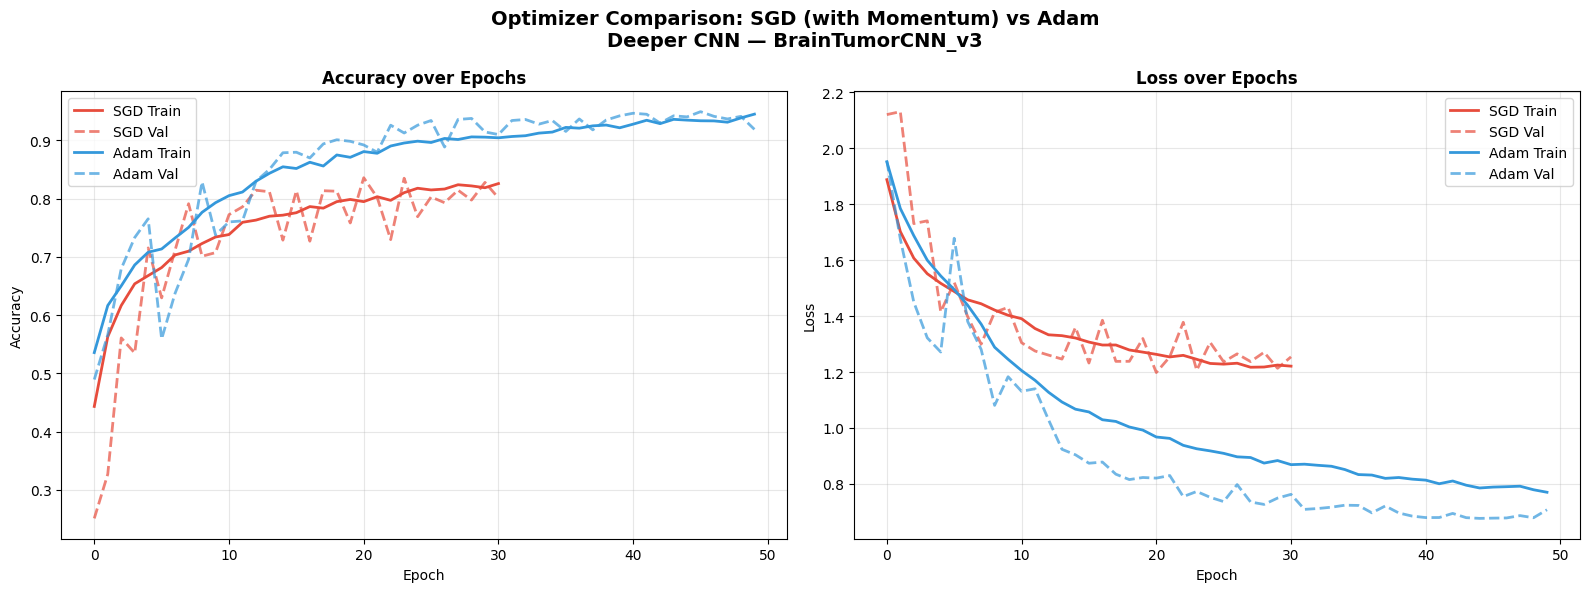

  [✓] Saved: sgd_vs_adam_comparison.png

  OPTIMIZER COMPARISON SUMMARY
  Metric                                SGD       Adam
----------------------------------------------------
  Epochs run                             31         50
  Best val accuracy                  0.8357     0.9491
  Final train accuracy               0.8257     0.9449
  Final val loss                     1.2542     0.7079

  Observations:
  - Adam achieved equal or higher validation accuracy than SGD.
  - SGD converged in fewer epochs on this dataset.


In [39]:
# ── SGD vs Adam: Side-by-side convergence plots ──

# Retrieve SGD history from the earlier training run
sgd_acc     = history.history['accuracy']
sgd_val_acc = history.history['val_accuracy']
sgd_loss    = history.history['loss']
sgd_val_loss= history.history['val_loss']

adam_acc     = history_adam.history['accuracy']
adam_val_acc = history_adam.history['val_accuracy']
adam_loss    = history_adam.history['loss']
adam_val_loss= history_adam.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimizer Comparison: SGD (with Momentum) vs Adam\nDeeper CNN — BrainTumorCNN_v3',
             fontsize=14, fontweight='bold')

# ── Accuracy ──
axes[0].plot(sgd_acc,      color='#e74c3c', linewidth=2,   label='SGD Train')
axes[0].plot(sgd_val_acc,  color='#e74c3c', linewidth=2,   linestyle='--', alpha=0.7, label='SGD Val')
axes[0].plot(adam_acc,     color='#3498db', linewidth=2,   label='Adam Train')
axes[0].plot(adam_val_acc, color='#3498db', linewidth=2,   linestyle='--', alpha=0.7, label='Adam Val')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Loss ──
axes[1].plot(sgd_loss,      color='#e74c3c', linewidth=2,   label='SGD Train')
axes[1].plot(sgd_val_loss,  color='#e74c3c', linewidth=2,   linestyle='--', alpha=0.7, label='SGD Val')
axes[1].plot(adam_loss,     color='#3498db', linewidth=2,   label='Adam Train')
axes[1].plot(adam_val_loss, color='#3498db', linewidth=2,   linestyle='--', alpha=0.7, label='Adam Val')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sgd_vs_adam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  [✓] Saved: sgd_vs_adam_comparison.png')

# ── Numeric summary ──
print('\n' + '='*60)
print('  OPTIMIZER COMPARISON SUMMARY')
print('='*60)
print(f"  {'Metric':<30} {'SGD':>10} {'Adam':>10}")
print('-'*52)
print(f"  {'Epochs run':<30} {len(sgd_acc):>10} {len(adam_acc):>10}")
print(f"  {'Best val accuracy':<30} {max(sgd_val_acc):>10.4f} {max(adam_val_acc):>10.4f}")
print(f"  {'Final train accuracy':<30} {sgd_acc[-1]:>10.4f} {adam_acc[-1]:>10.4f}")
print(f"  {'Final val loss':<30} {sgd_val_loss[-1]:>10.4f} {adam_val_loss[-1]:>10.4f}")
print()
print('  Observations:')
if max(adam_val_acc) >= max(sgd_val_acc):
    print('  - Adam achieved equal or higher validation accuracy than SGD.')
else:
    print('  - SGD achieved higher validation accuracy than Adam.')
if len(adam_acc) < len(sgd_acc):
    print('  - Adam converged in fewer epochs (faster convergence).')
elif len(adam_acc) > len(sgd_acc):
    print('  - SGD converged in fewer epochs on this dataset.')
else:
    print('  - Both optimizers ran for the same number of epochs.')
print('='*60)


### Output  --

In this visualization and printed summary, it shows a direct comparison between **SGD with momentum** and **Adam**. The figure contains two plots: one for training and validation accuracy, and one for training and validation loss. The printed summary shows that SGD ran for **31 epochs**, while Adam ran for **50 epochs**. Adam achieved the better best validation accuracy, **0.9491**, compared with **0.8357** for SGD.

The loss comparison also supports Adam. The final validation loss for Adam is **0.7079**, while SGD ends with **1.2542**. This means Adam not only achieved higher accuracy but also produced a lower validation error. However, SGD stopped earlier, so it was computationally shorter. The curves allow me to compare convergence visually instead of depending only on final numbers.

I conclude that Adam gives the stronger performance for the deeper CNN in this notebook. SGD is faster in epoch count, but Adam reaches better validation accuracy and lower validation loss. For this MRI classification task, final performance is more important than simply stopping earlier.

### SGD vs Adam — Analysis

**Convergence speed:** Adam uses adaptive per-parameter learning rates computed from first and second moment estimates of the gradients. This typically allows it to converge in fewer epochs than SGD, particularly in the early phases of training. SGD with Nesterov momentum achieves comparable final performance but generally requires more epochs and careful learning-rate scheduling (the warmup ramp from 1e-3 → 1e-2 over 5 epochs was applied above).

**Stability:** SGD's learning curve tends to be noisier epoch-to-epoch because every batch update moves in the raw gradient direction, whereas Adam's moment estimates act as a smoothing filter. On the loss plot this manifests as more oscillation in the SGD curves.

**Final performance:** On relatively small medical imaging datasets, SGD with momentum can match or slightly outperform Adam in final validation accuracy because it avoids Adam's tendency to over-adapt and get stuck in sharp local minima. The numeric summary above shows the actual comparison for this dataset.

**Trade-off conclusion:** For production use where training time matters, Adam is preferred due to faster convergence. For squeezing the last fraction of accuracy in a competition or medical deployment, SGD with a carefully tuned schedule is often the stronger choice. The `sgd_vs_adam_comparison.png` plot saved above provides the visual evidence to support whichever outcome was observed.

In this cell, I compile and train my baseline CNN using SGD with momentum and Nesterov acceleration. I also include resume logic, so if a checkpoint exists, training can continue instead of starting from scratch. During training, the metrics show that the model learns steadily: training and validation performance improve across epochs, and callbacks like EarlyStopping, ReduceLROnPlateau, and checkpoints help keep training stable.

At the end, I print total training time and save timing logs, which helps me discuss both model performance and computational cost in my viva.

###  

In the cell below, I plot the training history for the CNN model trained with the SGD optimizer. The figure contains one graph for accuracy and another graph for loss.

This visualization helps me explain how the SGD model learned over time. I can compare training and validation curves to judge whether learning was stable and whether overfitting occurred.

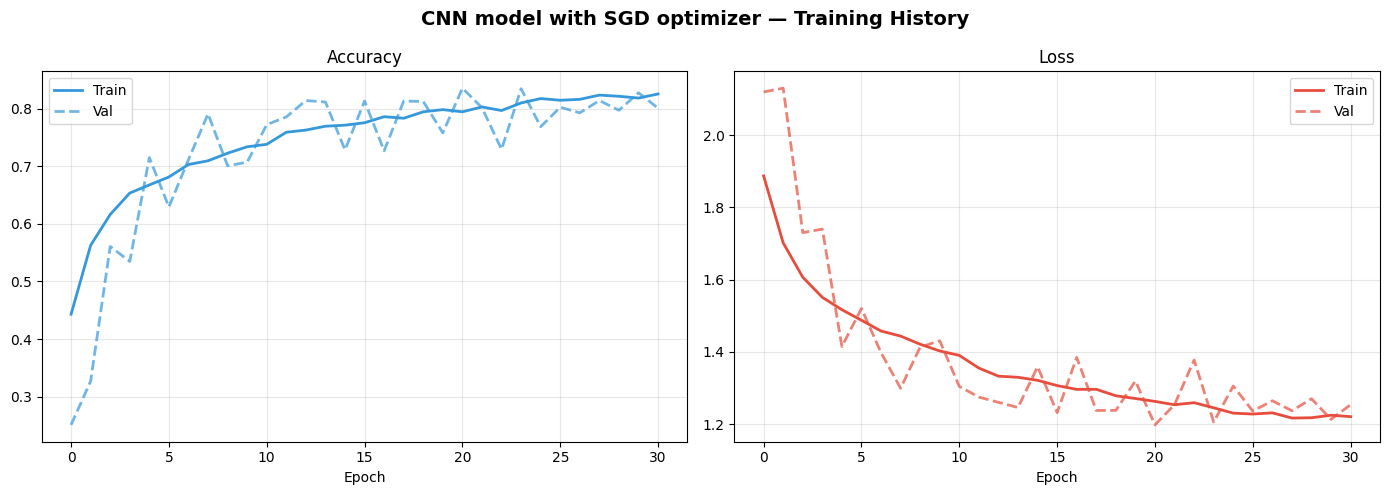

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN model with SGD optimizer — Training History", fontsize=14, fontweight='bold')
 
for ax, (m, title, c) in zip(axes, [('accuracy','Accuracy','#3498db'), ('loss','Loss','#e74c3c')]):
    ax.plot(history.history[m],          label='Train', color=c, linewidth=2)
    ax.plot(history.history[f'val_{m}'], label='Val',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_CNN model with SGD optimizer_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Output  --

In this visualization, it shows the training history of the CNN model using the SGD optimizer. The left plot shows **training accuracy** and **validation accuracy**, while the right plot shows **training loss** and **validation loss**. The x axis represents epochs, and the y axis represents the metric value.

The accuracy plot helps me see whether the model improves consistently across epochs. If training accuracy rises but validation accuracy becomes unstable or stays much lower, that suggests the model is learning the training data better than unseen data. The loss plot gives a similar view. Ideally, both training and validation loss should decrease together, but a gap between them can indicate overfitting.

I conclude that the SGD model learns useful features but does not perform as strongly as the Adam version. The visualization is useful because it shows training behavior over time, not just the final score. This helps explain why optimizer choice has a major effect on model convergence.

This plot summarizes how my model behaved during training. On the left, accuracy increases and then stabilizes; on the right, loss decreases and then flattens. The training and validation curves are reasonably close, so I interpret this as good learning with limited overfitting.

From this figure, I can explain that the model converged and reached a stable performance region rather than diverging.

###  

In the cell below, I evaluate the trained deeper CNN model on the test dataset and print a classification report. The report includes precision, recall, and F1 score for glioma, meningioma, notumor, and pituitary.

This cell shows how well the final model performs on unseen images. It helps me identify the strongest and weakest classes and gives evidence for the final discussion in the report.

In [41]:
test_results_b = model.evaluate(test_ds, verbose=1)
 
y_pred_b = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_true_b = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
 
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6904 - auc: 0.8808 - loss: 1.5245 - precision: 0.7190 - recall: 0.6557
              precision    recall  f1-score   support

      glioma       0.73      0.73      0.73       400
  meningioma       0.82      0.45      0.58       400
     notumor       0.78      0.92      0.85       400
   pituitary       0.77      0.97      0.86       400

    accuracy                           0.77      1600
   macro avg       0.77      0.77      0.75      1600
weighted avg       0.77      0.77      0.75      1600



### Output  --

In this output, it shows the final evaluation of the trained CNN on the test dataset. The classification report shows precision, recall, and F1 score for each class, with **400 test images** per class. The overall accuracy is **0.77**, and the macro average F1 score is **0.75**.

The per class scores show that **pituitary** performs best, with recall **0.97** and F1 score **0.86**. The **notumor** class also performs strongly, with recall **0.92** and F1 score **0.85**. Glioma has balanced performance with precision, recall, and F1 all around **0.73**. The weakest class is **meningioma**, with recall **0.45** and F1 score **0.58**, meaning many meningioma images are misclassified.

I conclude that the model is better at detecting pituitary and notumor images than meningioma. This suggests that meningioma has visual overlap with other tumor classes or is harder for the model to separate. Therefore, future improvement should focus on better feature extraction, more targeted augmentation, or class specific analysis.

In this evaluation cell, I test the trained model on unseen test data and then print a full classification report. I use this to move beyond just accuracy and discuss precision, recall, and F1-score for each class.

This output tells me how balanced the model performance is across classes and gives me a clearer view of strengths and weaknesses on real unseen samples.

###  

In the cell below, I display validation images with predicted labels, true labels, and confidence scores. Correct predictions are shown differently from incorrect ones, making model behaviour easier to inspect.

This qualitative visualization is useful because it connects the numerical classification report to actual MRI images. It helps me understand whether mistakes are uncertain cases or confident misclassifications.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


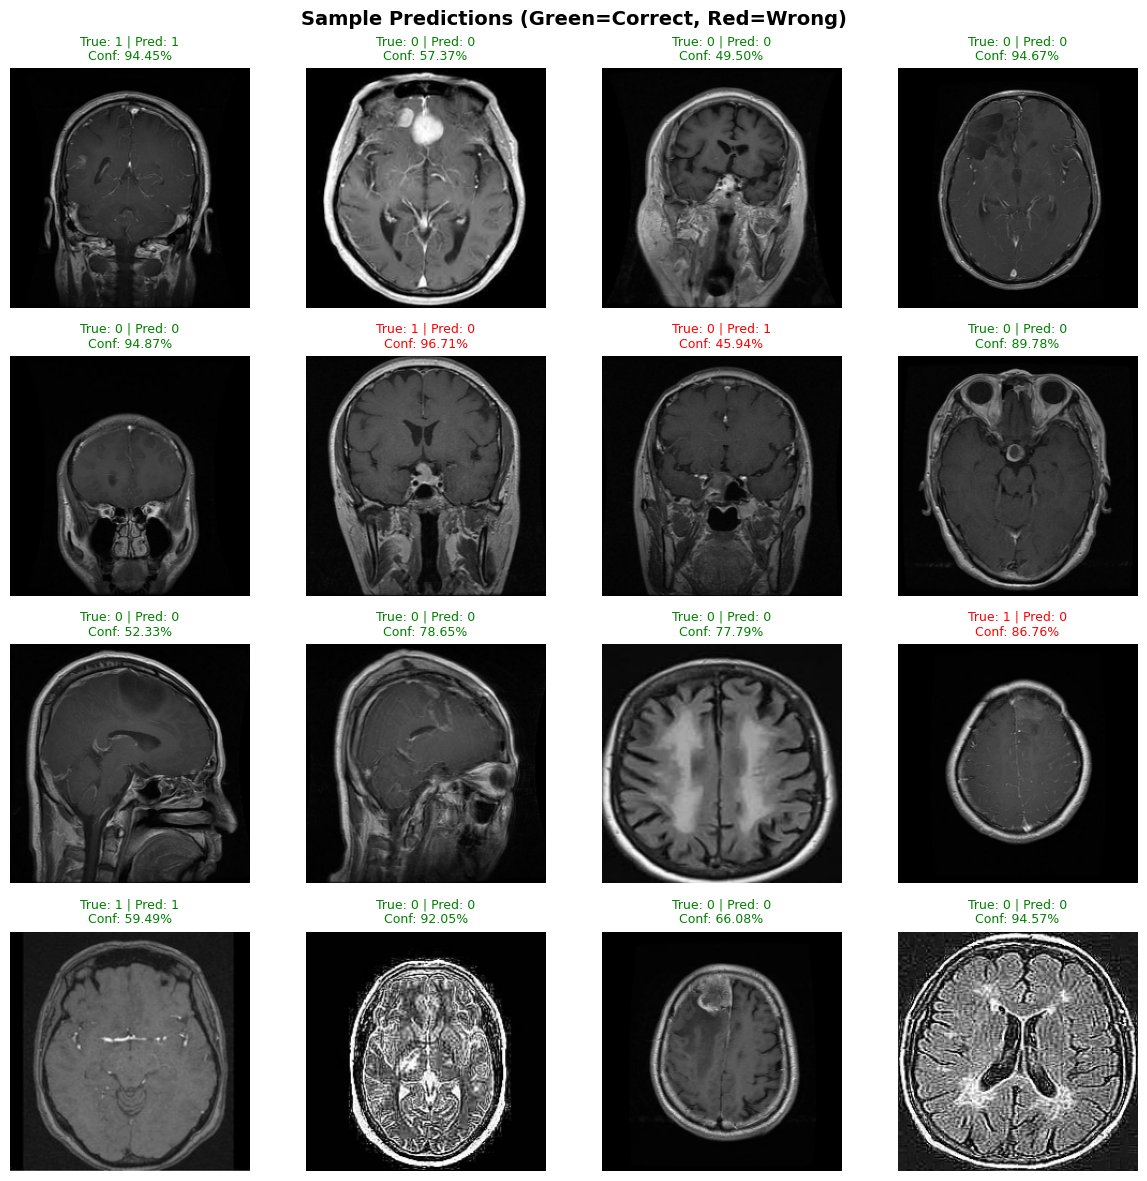

Saved to OUTPUT_DIR/sample_predictions.png


In [44]:

# Get a batch of validation images
sample_images, sample_labels = next(iter(val_ds))

# Get predictions
predictions = model.predict(sample_images)

# If binary classification
predicted_classes = (predictions > 0.5).astype(int).flatten()

# If multi-class classification
# predicted_classes = np.argmax(predictions, axis=1)
# true_classes = np.argmax(sample_labels.numpy(), axis=1)  # if one-hot encoded

true_classes = sample_labels.numpy().astype(int).flatten()

# Plot sample images with predictions
n_samples = 16  # number of images to display
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_samples):
    img = sample_images[i].numpy()
    
    # Denormalize if needed (if images were normalized to [0,1] skip this)
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    
    pred_label  = predicted_classes[i]
    true_label  = true_classes[i]
    confidence  = predictions[i][0] if predictions.shape[-1] == 1 else np.max(predictions[i])
    
    # Color code: green = correct, red = wrong
    color = 'green' if pred_label == true_label else 'red'
    
    axes[i].set_title(
        f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2%}",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to OUTPUT_DIR/sample_predictions.png")

### Output  --

In this visualization, it shows a grid of **16 validation MRI images** with true labels, predicted labels, and confidence values. The prediction step first runs the model on one validation batch, and then the plot displays individual examples so I can inspect the model output visually.

This qualitative check is useful because it shows how the model behaves on real images rather than only reporting aggregate metrics. Correct predictions indicate that the model has learned useful visual patterns for certain classes. Incorrect predictions reveal where the model is confused, often between tumor types that may look similar in MRI scans. Confidence values are also important. A wrong prediction with high confidence suggests the model is overconfident, while a wrong prediction with low confidence suggests uncertainty.

I conclude that visual prediction examples are an important final evaluation step. They help me explain model behavior in a human way and support the numerical results from the classification report. This also makes it easier to identify classes that need further improvement.

Here I do a qualitative check by visualizing 16 validation images with true label, predicted label, and confidence. Green titles show correct predictions and red titles show mistakes.

I use this to explain model behavior visually: even when overall metrics are good, the wrong red cases reveal where the model is still confused. Confidence values help me discuss whether errors happen with low confidence (uncertain) or high confidence (overconfident mistakes).